# Detecting Exoplanet Atmospheric Composition and Wind Speed via Cross-Correlation

---

## Learning Goals

- Understand the mathematical foundation of the cross-correlation function and how it applies to exoplanet spectra.

- Prepare observed and template spectra for cross-correlation, including wavelength conversion, detrending, and converting absorption spectra to emission format.

- Use cross-correlation with molecular templates to detect atmospheric composition, and interpret what a peak (or the absence of one) tells you.

- Estimate horizontal wind speeds in an exoplanet's atmosphere using cross-correlation.

- Examine how instrument resolution affects the accuracy of wind speed and composition measurements, using examples like NIRSpec and CRIRES.

## Table of Contents

- Imports

- High-Resolution Spectroscopy

    - Calculating the Original Resolution

    - Resolution Detrending

    - Separating the Planet's Signal

- Cross-Correlation Function

    - Cross-Correlation in NumPy and SciPy

    - Cross-Correlation of Two Uncorrelated Noise Signals

    - Cross-Correlation of Two Shifted Signals

    - Customized Cross-Correlation Function

- Composition Detection

    - Downloading Molecular Line Data from HITEMP

    - Preparing Molecular Templates

    - Cross-Correlation with the Planet Spectrum

- Wind Speed Measurement

    - Plotting Doppler-Off vs. Doppler-On Spectra

    - Estimating Wind Speed at Full Resolution

    - Effects of Instrument Resolution on Wind Speed Measurement

    - Resolution vs. Wind Speed Measurement Accuracy

- End of Tutorial

- References

- About This Notebook

## Imports

This tutorial relies on a few core Python packages for data processing, visualization, and computation:

- **numpy** – array operations and numerical computations

- **matplotlib** – plotting and visualizing spectra

- **scipy** – interpolation and filtering

- **pandas** – loading and managing tabular data

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage
from scipy.interpolate import interp1d, splev, splrep
import pandas as pd
import matplotlib.animation as animation

In [2]:
import file_paths

## High-Resolution Spectroscopy

High-resolution spectroscopy (HRS) is an observational technique used to study light from celestial objects at fine wavelength precision. The resolving power $R$ of a spectrograph is defined as:

$$
R = \frac{\lambda}{\Delta \lambda}
$$

where

- $\lambda$ is the observed wavelength.
- $\Delta \lambda$ is the smallest difference in wavelength the instrument can distinguish.

HRS resolves narrow absorption and emission lines that would otherwise blend together at lower resolution, making it possible to detect subtle Doppler shifts, separate closely spaced spectral features, and study gas motion and chemical composition in detail.

By dispersing light into many narrow channels, HRS reveals structures such as fine-structure transitions, isotopic shifts, and molecular vibration-rotation lines (Linsky et al., 2025). It can resolve lines from neutrals (H I, O I), ions (C II, N V, O VI), and molecules such as H$_2$ and CO. Typical HRS instruments operate at $R \gtrsim 25,000$, and precision measurements often call for $R \approx 100,000$.

### Calculating the Original Resolution

Knowing a spectrum's original resolution matters for cross-correlation analysis, since it sets the smallest detectable Doppler shift and affects how precisely we can measure velocity. The code below calculates the spectral resolution of a 3D model spectrum of WASP-121b (Beltz & Rauscher, 2024), an ultra-hot Jupiter with a mass of $1.16~\text{M}_{\text{J}}$ and a radius of $1.75~\text{R}_{\text{J}}$. It orbits its host star every 1.27 days at a distance of 0.026 AU and has an equilibrium temperature of about 2341 K (Bourrier et al., 2020), giving it an atmosphere hot enough to host atomic and molecular emission lines. These 3D model data files are available for download from this repository.

The first and last 10 data points are skipped to avoid edge noise. The calculation is wrapped in a reusable function so it works with different datasets.

In [3]:
def calculate_original_resolution(wavelength):
    # assume the dataset is detected on a wavelength grid
    wavelength_array = np.array(wavelength)

    # calculate original resolving power
    N = len(wavelength_array)
    delta_wl = np.abs(wavelength_array[-1] - wavelength_array[0]) / (N - 1)  # average spacing between wavelength points
    wl_mid = np.median(wavelength_array)  # median wavelength as a central reference
    R_orig = wl_mid / delta_wl  # resolving power from the equation above

    return R_orig

#### What the Function Does

1. Count the number of wavelength points.
2. Calculate the average spacing between points.
3. Find the median wavelength as the central reference.
4. Compute the resolving power using the formula above.

Here's an example of how this function works:

The original resolution of WASP-121b is 124,998


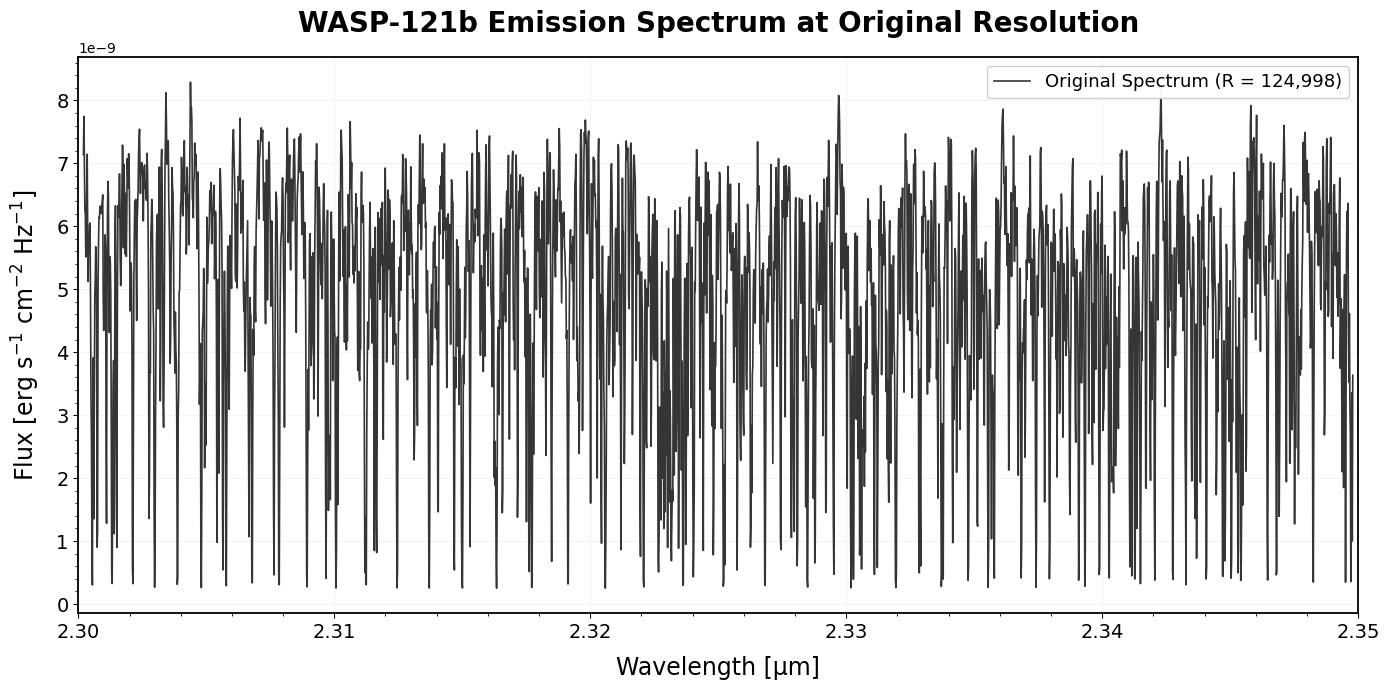

In [4]:
# read file
path_to_file_121 = 'Ideal Data/WASP-121b/W121b_emission/W121b_0G/Dop_OFF/IR/Spec_0_asp-121b-0G_IR_phase_0.0_inc_00.00.0000.00.dat'
df_121 = pd.read_csv(path_to_file_121, sep = '\t', header = None, names = ['wavelength', 'flux']).iloc[10:-10]  # ignore first and last 10 data points
wavelength_121 = df_121['wavelength'].values  # store wavelength values from dataframe
flux_121 = df_121['flux'].values  # store flux values from dataframe

# convert wavelength from meters to microns for readability
wavelength_121_um = wavelength_121 * 1e6

# calculate original resolution of WASP-121b
R_orig_121 = calculate_original_resolution(wavelength_121)
print(f'The original resolution of WASP-121b is {R_orig_121:,.0f}')

# zoom window where individual lines are visible
x_min, x_max = 2.30, 2.35

# set up the plot
plt.style.use('default')
fig, ax = plt.subplots(figsize = (14, 7))
fig.patch.set_facecolor('white')

ax.plot(
    wavelength_121_um, flux_121,
    label = f'Original Spectrum (R = {R_orig_121:,.0f})',
    linewidth = 1.2,
    alpha = 0.9,
    color = '#1f1f1f'
)

ax.set_xlim(x_min, x_max)

# titles and labels
ax.set_title('WASP-121b Emission Spectrum at Original Resolution', fontsize = 20, weight = 'bold', pad = 18)
ax.set_xlabel('Wavelength [μm]', fontsize = 17, labelpad = 10)
ax.set_ylabel(r'Flux [erg s$^{-1}$ cm$^{-2}$ Hz$^{-1}$]', fontsize = 17, labelpad = 10)

# legend
ax.legend(fontsize = 13, framealpha = 0.95, loc = 'upper right')

# clean grid and spines
ax.grid(True, alpha = 0.2, linestyle = '-', linewidth = 0.5)
ax.set_facecolor('white')

for spine in ax.spines.values():
    spine.set_linewidth(1.3)

# tick formatting
ax.minorticks_on()
ax.tick_params(axis = 'both', which = 'major', labelsize = 14)
ax.tick_params(axis = 'both', which = 'minor', labelsize = 12)

plt.tight_layout()
plt.show()

From the calculation above, the resolution of WASP-121b is approximately 125,000. This depends on how finely the model samples wavelength, not on any physical property of the planet itself. High resolution reveals fine spectral detail, as in the plot above, but it's often higher than what real instruments can achieve, which is what makes direct comparisons to observations difficult.

### Resolution Detrending

Model spectra like this one are typically at a much higher resolution than what real instruments can deliver. For reference:

- Near-Infrared Spectrograph (NIRSpec) on JWST: R $\approx$ 2,700 in high-resolution mode (Labiano et al., 2021).
- CRIRES+, a ground-based spectrograph: R $\approx$ 100,000 (Follert et al., n.d.).

Ground-based telescopes reach very high resolution but must contend with telluric absorption from Earth's atmosphere. Space-based instruments avoid that problem but generally operate at lower resolution. To compare our model to what an instrument would actually see, we detrend the spectrum to match its resolution.

The function below degrades a spectrum to a target resolution, simulating how the signal would look through a given instrument.

In [5]:
# define function to degrade resolution
def degrade_resolution(wavelength, flux, R_orig, R_target, lambda_mid = None, n_kernel = 4):
    if R_target >= R_orig:
        return flux.copy()  # return original flux if target resolution >= original

    if lambda_mid is None:
        lambda_mid = np.median(wavelength)  # calculate mid wavelength if not specified

    fwhm = np.sqrt(R_orig**2 - R_target**2) * (lambda_mid/(R_orig * R_target))  # calculate FWHM for Gaussian kernel
    sigma = fwhm/(2 * np.sqrt(2 * np.log(2)))  # convert FWHM to sigma for Gaussian kernel

    # kernel setup
    dx = np.mean(np.diff(wavelength))  # assume spacing between points is uniform
    kernel_x = np.arange(-n_kernel * sigma, n_kernel * sigma + dx, dx)  # kernel x-axis range

    # Gaussian kernel is a smooth, bell-shaped curve used to blur the flux.
    # it spreads each flux point over neighboring wavelengths according to the instrument's resolution.
    kernel = np.exp(-0.5 * (kernel_x/sigma)**2)  # Gaussian kernel to represent instrumental broadening
    kernel /= np.sum(kernel)  # normalize kernel so sum = 1

    origin = 0 if np.sum(kernel_x < 0) < np.sum(kernel_x > 0) else -1
    flux_conv = ndimage.convolve(flux, kernel, origin = origin)  # flux after degrading resolution

    return flux_conv

#### Input Parameters

| Parameter   | Description |
|------------|-------------|
| wavelength | Array of wavelength values |
| flux | Array of flux values of the planet's signal |
| R_orig | Original resolution of the signal |
| R_target | Resolution of the observing instrument |
| lambda_mid | (Optional) Central wavelength of the dataset; if not specified, the median wavelength is used |
| n_kernel | (Optional, default = 4) Kernel width multiplier |

#### What the Function Does

1. Check if the instrument resolution is higher than or equal to the original resolution.
2. If not, calculate the Gaussian kernel FWHM needed to blur the signal. A Gaussian kernel is a smooth, bell-shaped curve that spreads each flux point over neighboring wavelengths, simulating the instrument's finite resolution.
3. Convert FWHM to sigma and build the kernel over the wavelength spacing.
4. Convolve the flux with the kernel to obtain the detrended spectrum.

The output is a spectrum degraded to match the observing instrument's resolution.

Next, we apply this function to compare the WASP-121b spectrum across several instrument resolutions, from the original model down to JWST NIRSpec.

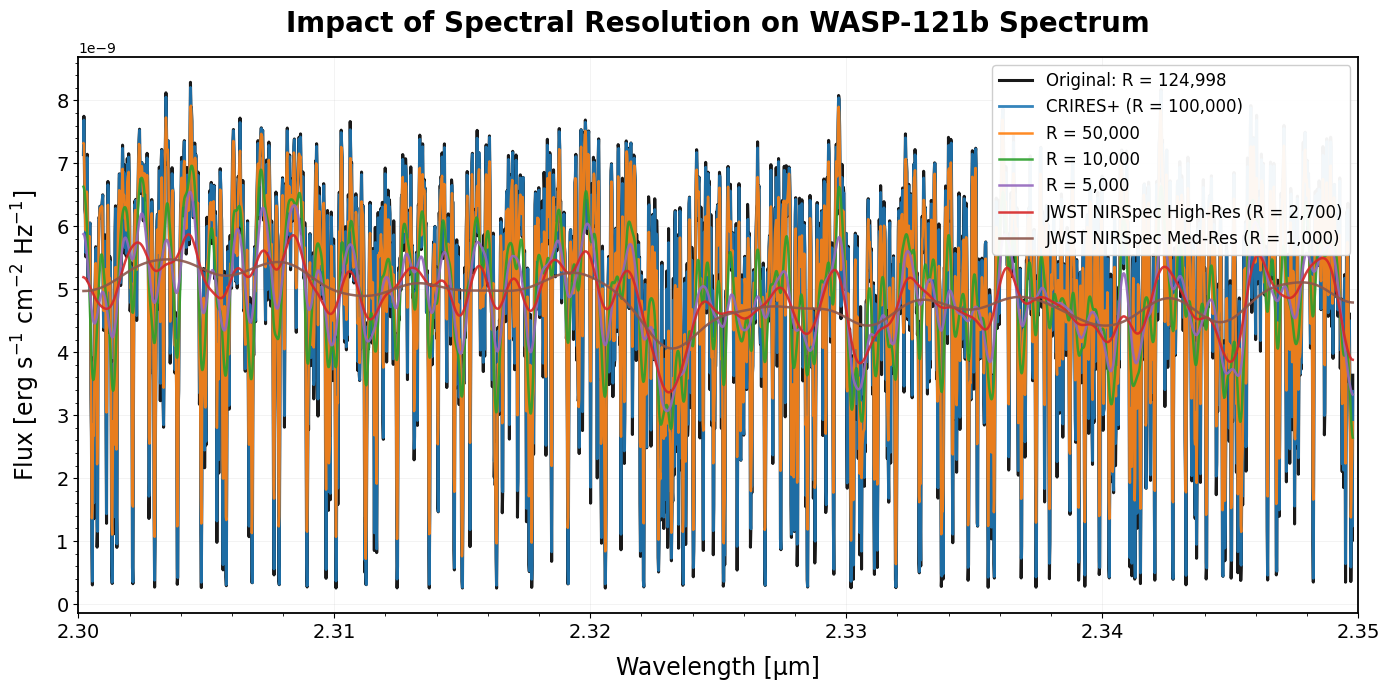

In [6]:
# resolutions spanning from the original model down to JWST NIRSpec med-res
instrument_resolutions = {
    'Original': R_orig_121,
    'CRIRES+ (R = 100,000)': 100000,
    'R = 50,000': 50000,
    'R = 10,000': 10000,
    'R = 5,000': 5000,
    'JWST NIRSpec High-Res (R = 2,700)': 2700,
    'JWST NIRSpec Med-Res (R = 1,000)': 1000,
}

# set up the plot
plt.style.use('default')
fig, ax = plt.subplots(figsize = (14, 7))
fig.patch.set_facecolor('white')

# distinct color palette for 7 lines
colors = ['black', 'tab:blue', 'tab:orange', 'tab:green', 'tab:purple', 'tab:red', 'tab:brown']
line_widths = [2.2, 2.0, 1.8, 1.8, 1.8, 1.8, 1.8]

for i, (label, R_target) in enumerate(instrument_resolutions.items()):
    flux_smoothed = degrade_resolution(wavelength_121, flux_121, R_orig_121, R_target)

    plot_label = f'Original: R = {R_orig_121:,.0f}' if label == 'Original' else label

    ax.plot(
        wavelength_121_um, flux_smoothed,
        label = plot_label,
        linewidth = line_widths[i],
        color = colors[i],
        alpha = 0.9
    )

# zoom into a narrow window where line blending is visually obvious
ax.set_xlim(2.30, 2.35)

# titles and labels
ax.set_title('Impact of Spectral Resolution on WASP-121b Spectrum', fontsize = 20, weight = 'bold', pad = 18)
ax.set_xlabel('Wavelength [μm]', fontsize = 17, labelpad = 10)
ax.set_ylabel(r'Flux [erg s$^{-1}$ cm$^{-2}$ Hz$^{-1}$]', fontsize = 17, labelpad = 10)

# legend
ax.legend(fontsize = 12, framealpha = 0.95, loc = 'upper right', ncol = 1)

# clean grid and spines
ax.grid(True, alpha = 0.2, linestyle = '-', linewidth = 0.5)
ax.set_facecolor('white')

for spine in ax.spines.values():
    spine.set_linewidth(1.3)

# tick formatting
ax.minorticks_on()
ax.tick_params(axis = 'both', which = 'major', labelsize = 14)
ax.tick_params(axis = 'both', which = 'minor', labelsize = 12)

plt.tight_layout()
plt.show()

The plot above shows the spectrum at several representative resolutions. The animation below shows the same effect as a continuous sweep, from R = 1,000 up to the original resolution, so you can see spectral detail emerge smoothly rather than in discrete jumps.

In [7]:
# continuous sweep in log space from R = 1,000 up to the original resolution
n_frames = 60
R_sequence_frames = np.logspace(np.log10(1000), np.log10(R_orig_121), n_frames)

fig, ax = plt.subplots(figsize = (14, 7))
fig.patch.set_facecolor('white')
line, = ax.plot([], [], color = 'tab:blue', linewidth = 1.8)
ax.set_xlim(2.30, 2.35)
ax.set_ylim(flux_121.min(), flux_121.max())
ax.set_xlabel('Wavelength [μm]', fontsize = 17, labelpad = 10)
ax.set_ylabel(r'Flux [erg s$^{-1}$ cm$^{-2}$ Hz$^{-1}$]', fontsize = 17, labelpad = 10)
ax.grid(True, alpha = 0.2, linestyle = '-', linewidth = 0.5)
ax.set_facecolor('white')
for spine in ax.spines.values():
    spine.set_linewidth(1.3)
ax.minorticks_on()
ax.tick_params(axis = 'both', which = 'major', labelsize = 14)
ax.tick_params(axis = 'both', which = 'minor', labelsize = 12)
title = ax.set_title('', fontsize = 20, weight = 'bold', pad = 18)

def update(frame):
    R_target = R_sequence_frames[frame]  # current resolution for this frame
    flux_deg = degrade_resolution(wavelength_121, flux_121, R_orig_121, R_target)  # degrade spectrum to this resolution
    line.set_data(wavelength_121_um, flux_deg)  # update the line with the degraded flux
    title.set_text(f'WASP-121b Spectrum at R = {R_target:,.0f}')  # update title with current resolution
    return line, title

ani = animation.FuncAnimation(fig, update, frames = len(R_sequence_frames), interval = 80, blit = False)

# requires ffmpeg to be installed on your system (or pip install imageio-ffmpeg)
ani.save('wasp121b_resolution.mp4', writer = 'ffmpeg', dpi = 120)
plt.close(fig)

<video controls width="100%">
  <source src="wasp121b_resolution.mp4" type="video/mp4">
  Your browser does not support the video tag.
</video>

As resolution decreases, the number of resolvable data points drops and the spectral lines broaden, exactly what the video above shows in reverse. Ground-based instruments typically achieve very high resolution but must contend with absorption from Earth's atmosphere. Space telescopes avoid atmospheric contamination but generally have lower resolution, resulting in less detailed signals. Both types of instruments have their advantages, but we won't explore those trade-offs in detail in this tutorial.

### Separating the Planet's Signal

The WASP-121b signal we've seen so far comes from high-resolution spectroscopy. In practice, isolating the planet's signal is more challenging. Even with thousands of spectral lines resolved, we still need to separate contributions from the host star and telluric absorption by Earth's atmosphere.

The key idea: the star and Earth's atmospheric signal are essentially stationary. The star does have its own motion, but it's far enough away that this motion is negligible over a typical observation. The planet, in contrast, moves fast, often tens to hundreds of km/s, so its spectral lines shift noticeably during an observation. That Doppler shift is what lets us separate the planet's signal from the stationary stellar and telluric components (Birkby, 2018).

This method has successfully detected molecules such as carbon monoxide in hot Jupiter atmospheres (Snellen et al., 2010). We'll explore the technique in detail next.

## Cross-Correlation Function

The cross-correlation function (CCF) measures the similarity between two datasets as a function of the displacement, or shift, of one relative to the other. It's sometimes described as a sliding dot product. The exact computation depends on whether the signals are continuous or discrete.

**Continuous case:**

Given two continuous functions f(t) and g(t), shift g(t) by a variable τ (time, wavelength, or another parameter). The cross-correlation is:

$$
\text{R}_{\text{fg}}(\tau) = \int_{-\infty}^{\infty} \text{f}(\text{t}) \, \text{g}(\text{t} + \tau) \, \text{dt}
$$

The result peaks where f(t) and the shifted g(t) align most closely.

**Discrete case:**

Given two discrete sequences f[n] and g[n], shift g[n] by an integer k. The cross-correlation is:

$$
\text{R}_{\text{fg}}(\text{k}) = \Sigma_{\text{n}} \text{f}(\text{n}) \, \text{g}(\text{n + k})
$$

Again, the peak occurs where the sequences are most similar.

In spectroscopy, we use the discrete form, since spectra are arrays of flux values in discrete wavelength bins. Python offers efficient implementations through NumPy and SciPy.

### Cross-Correlation in NumPy and SciPy

For most purposes, NumPy's version is enough:

```python
np.correlate(data_1, data_2, mode = '...')
```

- `data_1`, `data_2`: arrays representing the two signals.
- `mode`: `'valid'` (only full overlaps, length = max(0, len(a)-len(b)+1)), `'same'` (output length matches `data_1`, centered), or `'full'` (complete cross-correlation, including partial overlaps).

See the [NumPy correlate documentation](https://numpy.org/doc/stable/reference/generated/numpy.correlate.html) for details.

SciPy's version handles higher-dimensional arrays and offers a choice of computation method:

```python
from scipy import signal
signal.correlate(data_1, data_2, mode = '...', method = '...')
```

- `mode`: same options as NumPy.
- `method`: `'direct'` (direct computation), `'fft'` (Fast Fourier Transform), or `'auto'` (picks the faster method automatically).

See the [SciPy signal.correlate documentation](https://docs.scipy.org/doc/scipy-1.16.2/reference/generated/scipy.signal.correlate.html) for details.

For this tutorial, we'll use NumPy, starting with a simple example.

### Cross-Correlation of Two Uncorrelated Noise Signals

We generate two random Gaussian noise signals, s1 and s2. Since they're uncorrelated, we expect no significant peak in the cross-correlation, this demonstrates that the CCF doesn't create false positives.

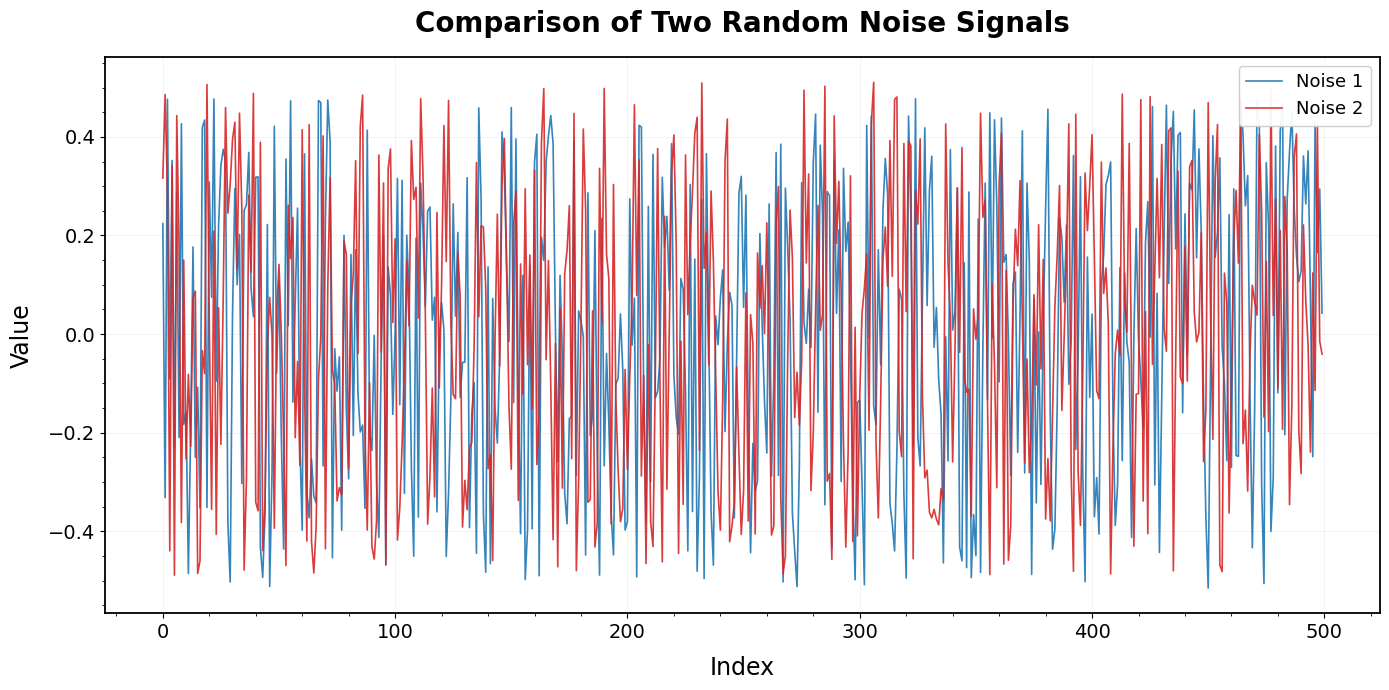

In [8]:
# generate independent random noise
noise_1 = np.random.uniform(0, 1, 500)
noise_2 = np.random.uniform(0, 1, 500)

# remove mean to prevent DC offset
noise_1 = noise_1 - np.mean(noise_1)
noise_2 = noise_2 - np.mean(noise_2)

# set up the plot
plt.style.use('default')
fig, ax = plt.subplots(figsize = (14, 7))
fig.patch.set_facecolor('white')

ax.plot(noise_1, label = 'Noise 1', color = '#1f77b4', linewidth = 1.2, alpha = 0.9)
ax.plot(noise_2, label = 'Noise 2', color = '#d62728', linewidth = 1.2, alpha = 0.9)

# titles and labels
ax.set_title('Comparison of Two Random Noise Signals', fontsize = 20, weight = 'bold', pad = 18)
ax.set_xlabel('Index', fontsize = 17, labelpad = 10)
ax.set_ylabel('Value', fontsize = 17, labelpad = 10)

# legend
ax.legend(fontsize = 13, framealpha = 0.95, loc = 'upper right')

# clean grid and spines
ax.grid(True, alpha = 0.2, linestyle = '-', linewidth = 0.5)
ax.set_facecolor('white')

for spine in ax.spines.values():
    spine.set_linewidth(1.3)

# tick formatting
ax.minorticks_on()
ax.tick_params(axis = 'both', which = 'major', labelsize = 14)
ax.tick_params(axis = 'both', which = 'minor', labelsize = 12)

plt.tight_layout()
plt.show()

Let's look at the cross-correlation using `np.correlate`:

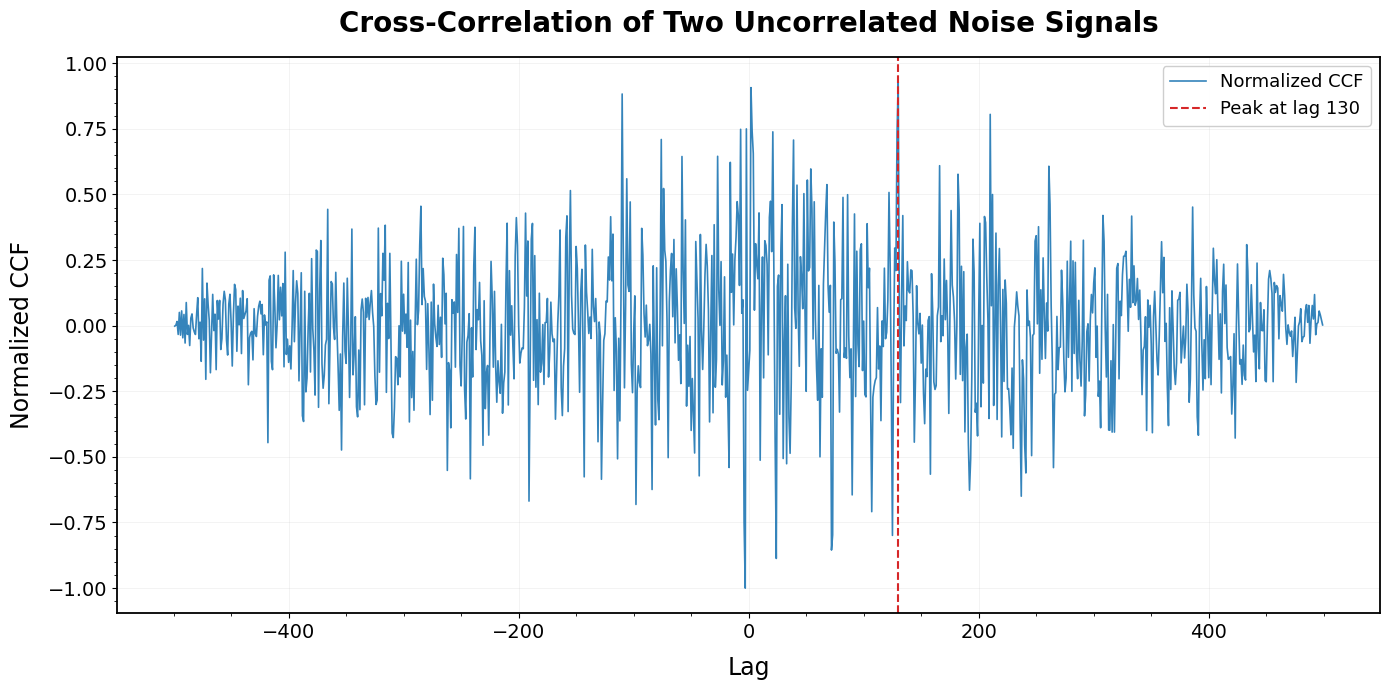

In [9]:
# cross correlation
ccf_noise = np.correlate(noise_1, noise_2, mode = 'full')
normalized_ccf_noise = ccf_noise / np.max(np.abs(ccf_noise))

# define lag axis
lags = np.arange(-len(noise_1) + 1, len(noise_1))

# find peak
peak_index = np.argmax(normalized_ccf_noise)
peak_lag = lags[peak_index]

# set up the plot
plt.style.use('default')
fig, ax = plt.subplots(figsize = (14, 7))
fig.patch.set_facecolor('white')

ax.plot(lags, normalized_ccf_noise, label = 'Normalized CCF', color = '#1f77b4', linewidth = 1.2, alpha = 0.9)
ax.axvline(x = peak_lag, color = '#d62728', linestyle = '--', linewidth = 1.5, label = f'Peak at lag {peak_lag}')

# titles and labels
ax.set_title('Cross-Correlation of Two Uncorrelated Noise Signals', fontsize = 20, weight = 'bold', pad = 18)
ax.set_xlabel('Lag', fontsize = 17, labelpad = 10)
ax.set_ylabel('Normalized CCF', fontsize = 17, labelpad = 10)

# legend
ax.legend(fontsize = 13, framealpha = 0.95, loc = 'upper right')

# clean grid and spines
ax.grid(True, alpha = 0.2, linestyle = '-', linewidth = 0.5)
ax.set_facecolor('white')

for spine in ax.spines.values():
    spine.set_linewidth(1.3)

# tick formatting
ax.minorticks_on()
ax.tick_params(axis = 'both', which = 'major', labelsize = 14)
ax.tick_params(axis = 'both', which = 'minor', labelsize = 12)

plt.tight_layout()
plt.show()

As expected, there's no strong peak. The cross-correlation function looks like noise, confirming that the CCF only responds to genuine similarity and doesn't produce false positives when signals are unrelated.

### Cross-Correlation of a Doppler-Shifted Signal

Let's look at a case closer to what an actual observation involves: a spectrum with absorption lines that has been Doppler-shifted relative to a reference template. Instead of testing a single fixed shift, we slide the template across a range of trial velocities and compute the CCF at each one, exactly how we'll later detect the real Doppler shift in WASP-121b's spectrum.

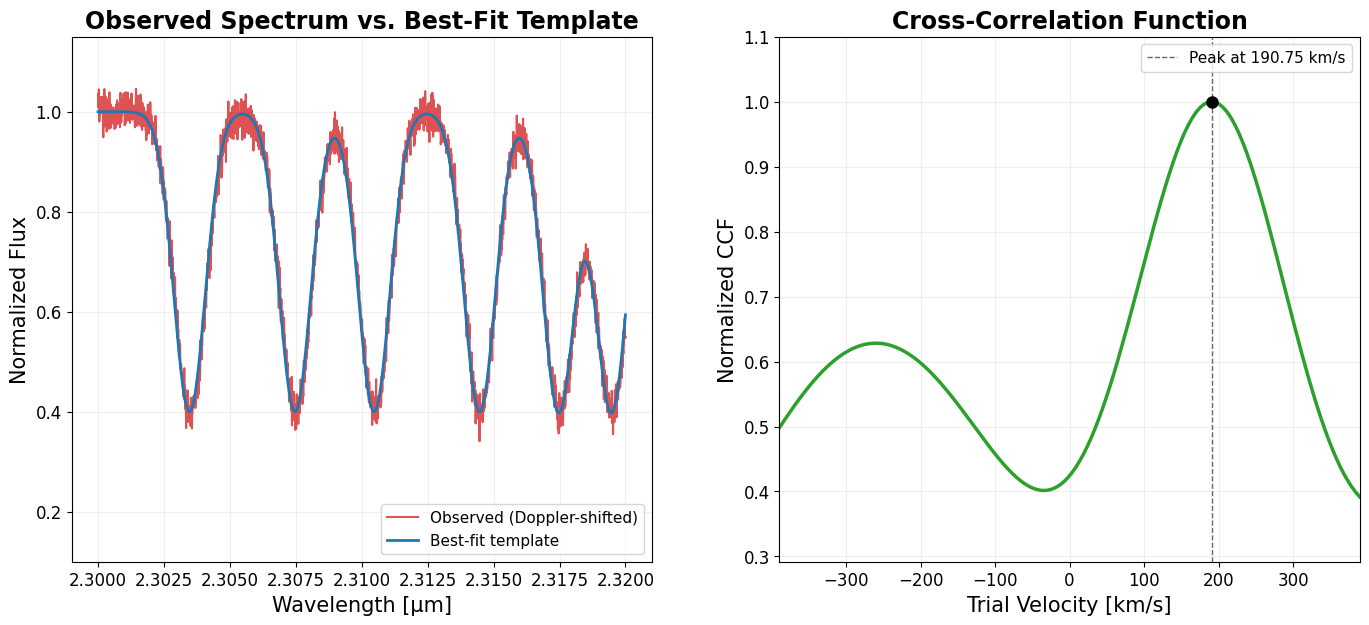

True injected shift: 194.67 km/s
Recovered peak shift: 190.75 km/s


In [10]:
# generate a synthetic "template" spectrum with several absorption lines
np.random.seed(0)
wavelength = np.linspace(2.30, 2.32, 2000)

def make_spectrum(wavelength, shift = 0.0):
    flux = np.ones_like(wavelength)
    line_centers = np.array([2.302, 2.306, 2.309, 2.313, 2.316, 2.318])
    for center in line_centers:
        flux -= 0.6 * np.exp(-0.5 * ((wavelength - (center + shift)) / 0.0006) ** 2)
    return flux

template_flux = make_spectrum(wavelength, shift = 0.0)
true_shift = 0.0015
observed_flux = make_spectrum(wavelength, shift = true_shift)
observed_flux += np.random.normal(0, 0.02, size = observed_flux.shape)

# convert trial wavelength shifts to trial velocities
trial_shifts = np.linspace(-0.003, 0.003, 150)
c_kms = 299792.458
lambda_mid = np.median(wavelength)
trial_velocity = (trial_shifts / lambda_mid) * c_kms

# compute the CCF at each trial shift
ccf_full = np.zeros_like(trial_shifts)
for i, s in enumerate(trial_shifts):
    shifted_template = make_spectrum(wavelength, shift = s)
    ccf_full[i] = np.sum((shifted_template - 1) * (observed_flux - 1))
ccf_full = ccf_full / np.max(ccf_full)

# find the peak of the CCF
peak_idx = np.argmax(ccf_full)
peak_velocity = trial_velocity[peak_idx]

# set up the static reference plot: final spectrum alignment and full CCF
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (14, 7))
fig.patch.set_facecolor('white')

# left panel: observed spectrum vs. best-fit shifted template
ax1.plot(wavelength, observed_flux, color = '#d62728', linewidth = 1.5, alpha = 0.8, label = 'Observed (Doppler-shifted)')
ax1.plot(wavelength, make_spectrum(wavelength, shift = trial_shifts[peak_idx]), color = '#1f77b4', linewidth = 2, label = 'Best-fit template')
ax1.set_xlabel('Wavelength [μm]', fontsize = 15)
ax1.set_ylabel('Normalized Flux', fontsize = 15)
ax1.set_title('Observed Spectrum vs. Best-Fit Template', fontsize = 17, weight = 'bold')
ax1.legend(fontsize = 11, loc = 'lower right')
ax1.grid(True, alpha = 0.2)
ax1.tick_params(labelsize = 12)
ax1.set_ylim(0.1, 1.15)

# right panel: full CCF with peak marked
ax2.plot(trial_velocity, ccf_full, linewidth = 2.5, color = '#2ca02c')
ax2.plot(peak_velocity, ccf_full[peak_idx], 'o', color = 'black', markersize = 8)
ax2.axvline(x = peak_velocity, color = 'black', linestyle = '--', linewidth = 1, alpha = 0.6, label = f'Peak at {peak_velocity:.2f} km/s')
ax2.set_xlim(trial_velocity.min(), trial_velocity.max())
ax2.set_ylim(min(ccf_full) - 0.1, 1.1)
ax2.set_xlabel('Trial Velocity [km/s]', fontsize = 15)
ax2.set_ylabel('Normalized CCF', fontsize = 15)
ax2.set_title('Cross-Correlation Function', fontsize = 17, weight = 'bold')
ax2.legend(fontsize = 11, loc = 'upper right')
ax2.grid(True, alpha = 0.2)
ax2.tick_params(labelsize = 12)

fig.subplots_adjust(top = 0.88, bottom = 0.13, left = 0.06, right = 0.98, wspace = 0.22)
plt.show()

# report the true shift in velocity units, for reference in the text below
true_shift_velocity = (true_shift / lambda_mid) * c_kms
print(f'True injected shift: {true_shift_velocity:.2f} km/s')
print(f'Recovered peak shift: {peak_velocity:.2f} km/s')

The CCF peaks close to the true injected shift printed above, confirming that cross-correlation recovers the Doppler shift even with noise added to the observed spectrum. To see how the CCF actually builds up as the template slides across the spectrum, the video below animates the same process step by step.

In [11]:
# continuous sweep already computed: trial_velocity, ccf_full, trial_shifts
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (14, 7))
fig.patch.set_facecolor('white')

ax1.plot(wavelength, observed_flux, color = '#d62728', linewidth = 1.5, alpha = 0.8, label = 'Observed (Doppler-shifted)')
template_line, = ax1.plot([], [], color = '#1f77b4', linewidth = 2, label = 'Trial template (sliding)')
ax1.set_xlabel('Wavelength [μm]', fontsize = 15)
ax1.set_ylabel('Normalized Flux', fontsize = 15)
ax1.set_title('Sliding the Template', fontsize = 17, weight = 'bold')
ax1.legend(fontsize = 11, loc = 'lower right')
ax1.grid(True, alpha = 0.2)
ax1.tick_params(labelsize = 12)
ax1.set_ylim(0.1, 1.15)

# fixed-length array, padded with NaN for points not yet "revealed"
ccf_display = np.full_like(ccf_full, np.nan)
ccf_line, = ax2.plot(trial_velocity, ccf_display, linewidth = 2.5, color = '#2ca02c')
point, = ax2.plot([], [], 'o', color = 'black', markersize = 8)
ax2.set_xlim(trial_velocity.min(), trial_velocity.max())
ax2.set_ylim(min(ccf_full) - 0.1, 1.1)
ax2.set_xlabel('Trial Velocity [km/s]', fontsize = 15)
ax2.set_ylabel('Normalized CCF', fontsize = 15)
ax2.set_title('Cross-Correlation Function', fontsize = 17, weight = 'bold')
ax2.grid(True, alpha = 0.2)
ax2.tick_params(labelsize = 12)

fig.subplots_adjust(top = 0.88, bottom = 0.13, left = 0.06, right = 0.98, wspace = 0.22)

def update(frame):
    shifted_template = make_spectrum(wavelength, shift = trial_shifts[frame])
    template_line.set_data(wavelength, shifted_template)

    ccf_display[:frame + 1] = ccf_full[:frame + 1]  # reveal up to current frame, rest stays NaN
    ccf_line.set_data(trial_velocity, ccf_display)  # always same length
    point.set_data([trial_velocity[frame]], [ccf_full[frame]])
    return template_line, ccf_line, point

ani = animation.FuncAnimation(fig, update, frames = len(trial_shifts), interval = 50, blit = False)

# requires ffmpeg to be installed on your system (or pip install imageio-ffmpeg)
ani.save('cross_correlation_animation.mp4', writer = 'ffmpeg', dpi = 120)
plt.close(fig)

<video controls width="100%">
  <source src="cross_correlation_animation.mp4" type="video/mp4">
  Your browser does not support the video tag.
</video>

This is the same principle we'll use to measure WASP-121b's wind speed later in this tutorial.

### Customized Cross-Correlation Function

Now we combine everything into a custom CCF function for analyzing exoplanet spectra: detecting wind speed by comparing a Doppler-off (no wind) spectrum against a Doppler-on (with wind) spectrum, or detecting molecular composition by comparing the planet's spectrum against a molecular template.

In [12]:
# define function to cross-correlate between doppler off (no wind) and doppler on (with wind)
def cross_correlation_velocity_shift(wavelength_off, flux_off, wavelength_on, flux_on, R_target, velocity_range = 20, nc = 300, plot = True):
    c = 299792.458  # speed of light in km/s

    # calculate original spectral resolution from doppler-off file using median pixel-by-pixel method
    N = len(wavelength_off)
    delta_lambda_off = (wavelength_off[-1] - wavelength_off[0]) / (N - 1)
    lambda_mid = np.median(wavelength_off)
    R_orig = lambda_mid / delta_lambda_off

    # degrade both spectra to the same resolution for comparison
    flux_off_target = degrade_resolution(wavelength_off, flux_off, R_orig, R_target)
    flux_on_target  = degrade_resolution(wavelength_on,  flux_on,  R_orig, R_target)

    # find wavelength region where both spectra overlap
    min_wl_shared = max(np.min(wavelength_off), np.min(wavelength_on))
    max_wl_shared = min(np.max(wavelength_off), np.max(wavelength_on))
    mask_off = (wavelength_off >= min_wl_shared) & (wavelength_off <= max_wl_shared)
    mask_on  = (wavelength_on  >= min_wl_shared) & (wavelength_on  <= max_wl_shared)

    # extract overlapping region
    wavelength_off_shared = wavelength_off[mask_off]
    flux_off_shared       = flux_off_target[mask_off]
    wavelength_on_shared  = wavelength_on[mask_on]
    flux_on_shared        = flux_on_target[mask_on]

    # sort by wavelength (required for interpolation)
    sort_idx_off          = np.argsort(wavelength_off_shared)
    sort_idx_on           = np.argsort(wavelength_on_shared)
    wavelength_off_sorted = wavelength_off_shared[sort_idx_off]
    wavelength_on_sorted  = wavelength_on_shared[sort_idx_on]
    flux_off_sorted       = flux_off_shared[sort_idx_off]
    flux_on_sorted        = flux_on_shared[sort_idx_on]

    # remove any NaN or infinite values
    valid_off            = np.isfinite(flux_off_sorted) & np.isfinite(wavelength_off_sorted)
    valid_on             = np.isfinite(flux_on_sorted)  & np.isfinite(wavelength_on_sorted)
    wavelength_off_clean = wavelength_off_sorted[valid_off]
    flux_off_clean       = flux_off_sorted[valid_off]
    wavelength_on_clean  = wavelength_on_sorted[valid_on]
    flux_on_clean        = flux_on_sorted[valid_on]

    # interpolate observed spectrum onto template's wavelength grid
    flux_on_interp = np.interp(wavelength_off_clean, wavelength_on_clean, flux_on_clean)

    # subtract mean to remove continuum (pre-whitening)
    template = flux_off_clean - np.mean(flux_off_clean)   # f(n) = no wind
    observed = flux_on_interp - np.mean(flux_on_interp)   # g(n) = with wind

    # set up velocity grid to test
    velocity_lags = np.linspace(-velocity_range, velocity_range, nc)
    ccf           = np.zeros_like(velocity_lags)

    # wavelength spacing and midpoint for velocity conversion
    delta_lambda = wavelength_off_clean[1] - wavelength_off_clean[0]
    lambda_mid   = np.median(wavelength_off_clean)
    N_full       = len(template)  # build spline model from template spectrum for smooth shifting
    indices         = np.arange(N_full)
    template_spline = splrep(indices, template, s = 0)

    # try each possible wind velocity
    for i, v in enumerate(velocity_lags):
        # convert velocity to pixel shift
        shift_pixels = - (lambda_mid * (v / c)) / delta_lambda

        # shift the template using spline interpolation
        shifted_indices  = indices + shift_pixels
        template_shifted = splev(shifted_indices, template_spline)

        # create weights that smoothly go to zero at the edges
        weight = np.ones_like(shifted_indices)

        # taper edges over 10% of the array
        edge_width = int(N_full * 0.1)
        for j in range(edge_width):
            weight[j]        = (j / edge_width)  # linear ramp up at start
            weight[-(j + 1)] = (j / edge_width)  # linear ramp down at end

        # apply weights to both spectra
        template_weighted = template_shifted * weight
        observed_weighted = observed         * weight

        # calculate weighted cross-correlation
        sum_weights = np.sum(weight)
        R_x         = np.sum(template_weighted * observed_weighted) / sum_weights

        # calculate weighted standard deviations
        var_template_weighted = np.sum(weight * (template_weighted - np.average(template_weighted, weights = weight))**2) / sum_weights
        var_observed_weighted = np.sum(weight * (observed_weighted - np.average(observed_weighted, weights = weight))**2) / sum_weights

        ccf[i] = R_x / np.sqrt(var_template_weighted * var_observed_weighted)

    # normalize ccf after loop is complete
    ccf_normalized = (ccf - np.min(ccf)) / (np.max(ccf) - np.min(ccf))

    # find velocity that gives highest correlation
    v_peak = velocity_lags[np.argmax(ccf)]

    # plot results if requested
    if plot:
        plt.style.use('default')
        fig, ax = plt.subplots(figsize = (14, 7))
        fig.patch.set_facecolor('white')

        ax.plot(velocity_lags, ccf, label = f'R = {R_target:,.0f}', linewidth = 1.8, color = '#1f77b4')
        ax.axhline(y = 0, color = 'black', linestyle = '-', alpha = 0.3)
        ax.axvline(x = 0, color = 'gray', linestyle = '--', alpha = 0.5, label = 'Zero wind')
        ax.axvline(x = v_peak, color = '#d62728', linestyle = '--', alpha = 0.8, label = f'Peak = {v_peak:.2f} km/s')

        ax.set_title('Cross-Correlation Function: Peak Marks the Best-Fit Wind Velocity', fontsize = 20, weight = 'bold', pad = 18)
        ax.set_xlabel('Tested Wind Velocity [km/s]', fontsize = 17, labelpad = 10)
        ax.set_ylabel('Cross-Correlation Coefficient', fontsize = 17, labelpad = 10)
        ax.legend(fontsize = 13, framealpha = 0.95, loc = 'upper right')
        ax.grid(True, alpha = 0.2, linestyle = '-', linewidth = 0.5)
        ax.set_facecolor('white')

        for spine in ax.spines.values():
            spine.set_linewidth(1.3)

        ax.minorticks_on()
        ax.tick_params(axis = 'both', which = 'major', labelsize = 14)
        ax.tick_params(axis = 'both', which = 'minor', labelsize = 12)

        plt.tight_layout()
        plt.show()

    return velocity_lags, ccf, ccf_normalized, v_peak

#### Input Parameters

| Parameter | Description |
|---|---|
| `wavelength_off`, `flux_off` | Wavelength and flux arrays for the no-wind (Doppler-off) spectrum |
| `wavelength_on`, `flux_on` | Wavelength and flux arrays for the wind-affected (Doppler-on) spectrum, or a molecular template |
| `R_target` | Target instrument resolution |
| `velocity_range` | Max velocity (km/s) to test in the CCF |
| `nc` | Number of velocity points to test |
| `plot` | Whether to plot the CCF |

Two spectra go into this function:

1. **Doppler-off** (`wavelength_off`, `flux_off`): a reference spectrum of the planet's atmosphere without wind or Doppler shifts, or a molecular template.
2. **Doppler-on** (`wavelength_on`, `flux_on`): the spectrum we're testing, which may include Doppler shifts from atmospheric wind or planetary motion.

Cross-correlating the two lets us detect velocity shifts in the planetary atmosphere by measuring how far the second spectrum is shifted relative to the reference. The peak of the cross-correlation function marks the dominant velocity, whether that's wind speed or a molecular match at zero shift.

#### What the Function Does

1. Calculate the original spectral resolution from the Doppler-off spectrum. Both spectra share the same grid, so this resolution applies to both.

2. Degrade both spectra to the target resolution, so they're directly comparable.

3. Restrict the analysis to the wavelength range where both spectra overlap.

4. Sort, clean, and align the spectra: sort by wavelength, remove NaN or infinite values, and interpolate the Doppler-on flux onto the Doppler-off wavelength grid.

5. Subtract the mean from each spectrum to remove the continuum.

6. Build a smooth spline model of the Doppler-off spectrum, so it can be evaluated at any shifted wavelength.

7. For each trial velocity, shift the spline-modeled spectrum accordingly, taper the edges to avoid artifacts, and compute the weighted cross-correlation coefficient.

8. Normalize the resulting CCF and find the velocity at its peak, this is the best-fit Doppler shift.

9. Optionally plot the CCF against velocity, with the peak marked.

10. Return the velocity grid, the raw CCF, the normalized CCF, and the peak velocity.

## Composition Detection

Now we'll use the custom cross-correlation function to detect the molecular composition of WASP-121b. The dataset contains carbon monoxide (CO) emission (Beltz & Rauscher, 2024), so cross-correlating the planet's spectrum with a CO template should produce a clear peak at 0 km/s. Testing a species that isn't actually present, like nitric oxide (NO), should produce no meaningful peak.

### Downloading Molecular Line Data from HITEMP

We'll use line-by-line molecular data from HITEMP to build our template. This tutorial focuses on carbon monoxide (CO), but the same steps work for other species.

- HITEMP data can be downloaded from the [HITEMP official website](https://hitran.org/hitemp/).
- For convenience, this repository also includes the CO file used here.

In [13]:
# file path to CO data
file_path_CO = '05_HITEMP2019.par'
colspecs = [
    (0, 2),    # molecule number
    (2, 3),    # isotope number
    (3, 15),   # wavenumber [cm^-1]
    (15, 25),  # intensity [cm/molecule]
    (25, 35),  # Einstein A-coefficient
    (35, 40),  # air-broadened half-width
    (40, 45),  # self-broadened half-width
    (45, 55),  # lower state energy
]
names = ['molecule_number', 'isotope_number', 'wavenumber', 'intensity', 'einstein_a', 'air_half_width', 'self_half_width', 'lower_state_energy']
df_CO = pd.read_fwf(file_path_CO, colspecs = colspecs, names = names)
print(df_CO)

        molecule_number  isotope_number    wavenumber      intensity  \
0                     5               5      2.248764  2.700000e-164   
1                     5               5      2.279785  6.503000e-162   
2                     5               6      2.288013  3.667000e-166   
3                     5               5      2.310683  1.737000e-159   
4                     5               6      2.320259  8.961000e-164   
...                 ...             ...           ...            ...   
752971                5               1  22147.135667   1.804000e-31   
752972                5               1  22147.866612   2.015000e-31   
752973                5               1  22147.897630   1.933000e-31   
752974                5               1  22148.263252   2.038000e-31   
752975                5               1  22148.273542   2.011000e-31   

          einstein_a  air_half_width  self_half_width  lower_state_energy  
0       8.704000e-07          0.0797            0.086      

The dataset gives wavenumber in cm⁻¹, so we convert it to wavelength in meters:

$$
\lambda = \frac{1}{100 \cdot \text{wavenumber}}
$$

Multiplying by 100 converts cm⁻¹ to m⁻¹, and taking the reciprocal gives wavelength in meters. We also restrict the data to the wavelength range covered by the WASP-121b spectrum.

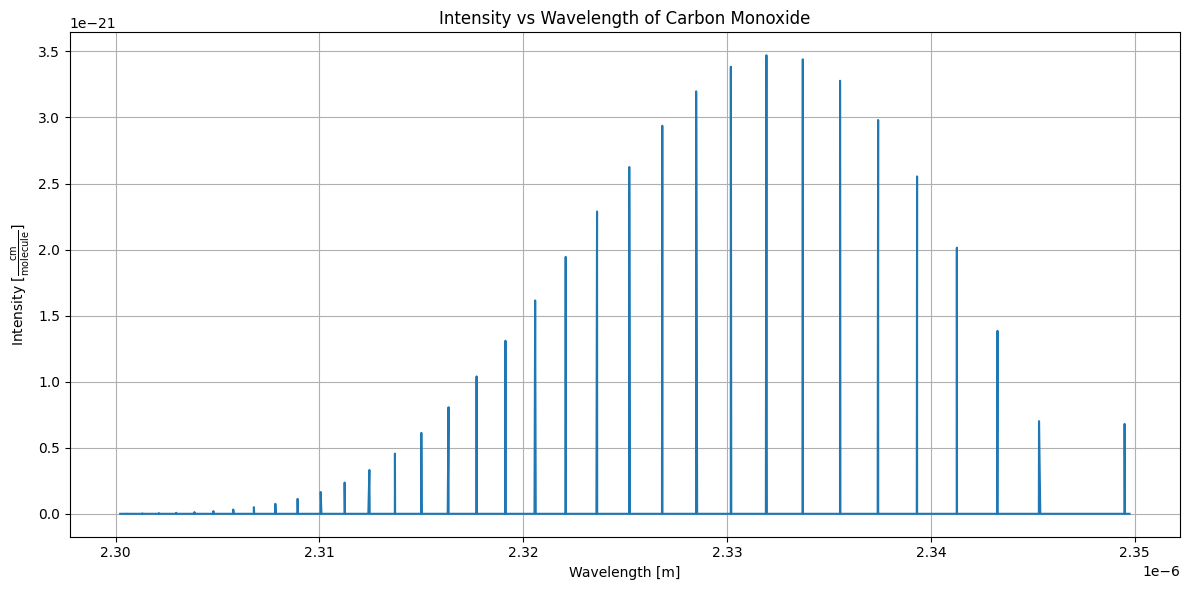

In [14]:
# change wavenumber to wavelength in meters
df_CO['wavelength_m'] = 1 / (100 * df_CO['wavenumber'])  # m

# sort for proper plotting
df_CO_sorted = df_CO.sort_values('wavelength_m')
wl_min = np.min(wavelength_121)
wl_max = np.max(wavelength_121)
df_CO_sorted = df_CO_sorted[(df_CO_sorted['wavelength_m'] >= wl_min) & (df_CO_sorted['wavelength_m'] <= wl_max)]

# plot
plt.figure(figsize = (12, 6))
plt.plot(df_CO_sorted['wavelength_m'], df_CO_sorted['intensity'])
plt.xlabel('Wavelength [m]')
plt.ylabel('Intensity [$\\frac{\\text{cm}}{\\text{molecule}}$]')
plt.title('Intensity vs Wavelength of Carbon Monoxide')
plt.grid(True)
plt.tight_layout()
plt.show()

### Preparing Molecular Templates

The HITEMP dataset is an absorption spectrum, but our planet's signal is emission, so we invert the intensity to convert it into an emission template. The result is saved in the same format the cross-correlation function expects.

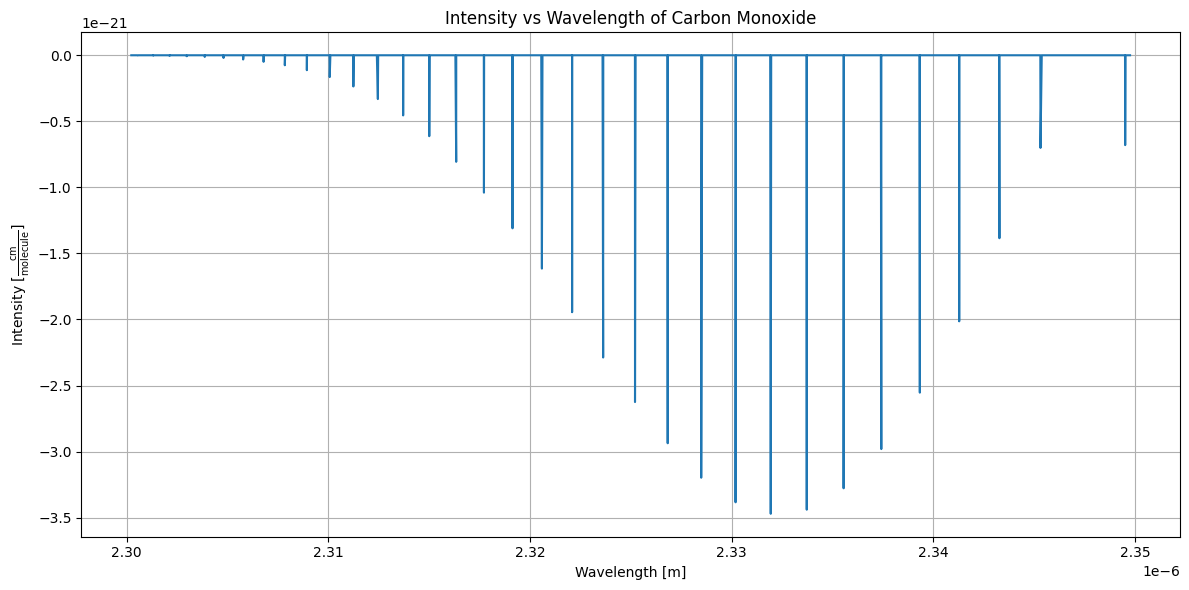

In [15]:
# visualize HITEMP emission spectrum
df_CO_sorted['intensity'] = -df_CO_sorted['intensity']
plt.figure(figsize = (12, 6))
plt.plot(df_CO_sorted['wavelength_m'], df_CO_sorted['intensity'])
plt.xlabel('Wavelength [m]')
plt.ylabel('Intensity [$\\frac{\\text{cm}}{\\text{molecule}}$]')
plt.title('Intensity vs Wavelength of Carbon Monoxide')
plt.grid(True)
plt.tight_layout()
plt.show()

# save processed CO spectrum in the same format as the function above
filename_CO = "CO_spectrum.txt"
df_CO_save = df_CO_sorted[['wavelength_m', 'intensity']].copy()
df_CO_save.columns = ['wavelength', 'intensity']

# save to tab-separated file, without headers and keeping formatting
df_CO_save.to_csv(filename_CO, sep = '\t', index = False, header = False)

### Cross-Correlation with the Planet Spectrum

Now we're ready to cross-correlate the CO template with the observed spectrum of WASP-121b. If CO is present, we expect a strong peak at 0 km/s. This repository also includes `CO_spectrum.txt` in case you weren't able to download the data yourself.

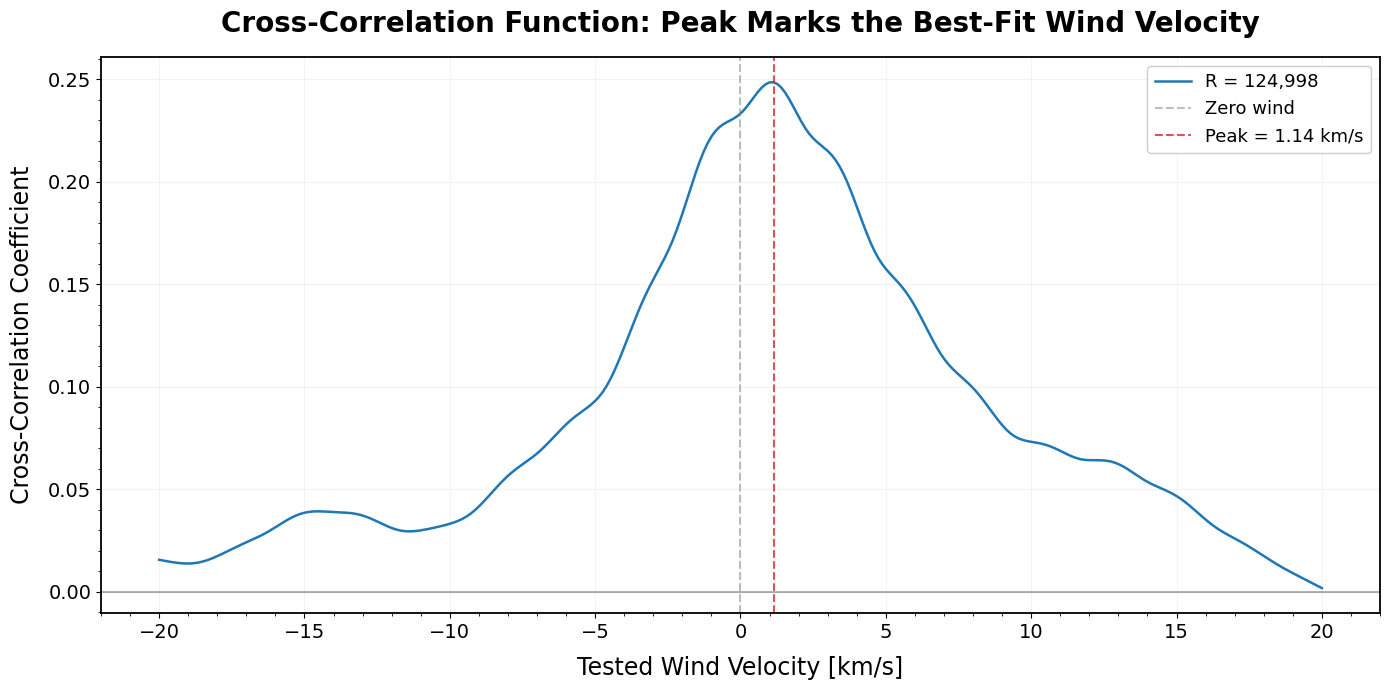

Velocity peak = 1.14 km/s
CCF peak strength = 0.2486


In [16]:
# load the CO template
filename_CO = 'CO_spectrum.txt'
df_CO_template = pd.read_csv(filename_CO, sep = '\t', header = None, names = ['wavelength', 'flux'])
wavelength_CO = df_CO_template['wavelength'].values
flux_CO = df_CO_template['flux'].values

# cross-correlate the CO template against the WASP-121b spectrum
vel_lags, ccf_vals, ccf_norm, v_peak = cross_correlation_velocity_shift(
    wavelength_off = wavelength_CO,
    flux_off       = flux_CO,
    wavelength_on  = wavelength_121,
    flux_on        = flux_121,
    R_target       = calculate_original_resolution(wavelength_121),
    velocity_range = 20,
    plot           = True
)

print(f'Velocity peak = {v_peak:.2f} km/s')
print(f'CCF peak strength = {np.max(ccf_vals):.4f}')

The cross-correlation shows a clear peak close to 0 km/s (1.14 km/s) with a correlation strength of about 0.25, confirming that WASP-121b's spectrum contains CO emission. This validates the custom cross-correlation function for detecting molecular composition.

> **Note:** the peak doesn't land at exactly 0 km/s. A small residual offset like this is common in practice, since the line list used to generate the template (HITEMP, here) and the line list used to simulate the planet's spectrum aren't always perfectly identical in their line-center wavelengths. What matters for confirming a detection is a clear, strong peak near zero, not exact alignment down to the last decimal.

We can test the same approach with a molecule that isn't present, nitric oxide (NO), following the same steps: read, convert, invert, and save the template. A pre-prepared NO template is also included in this repository.

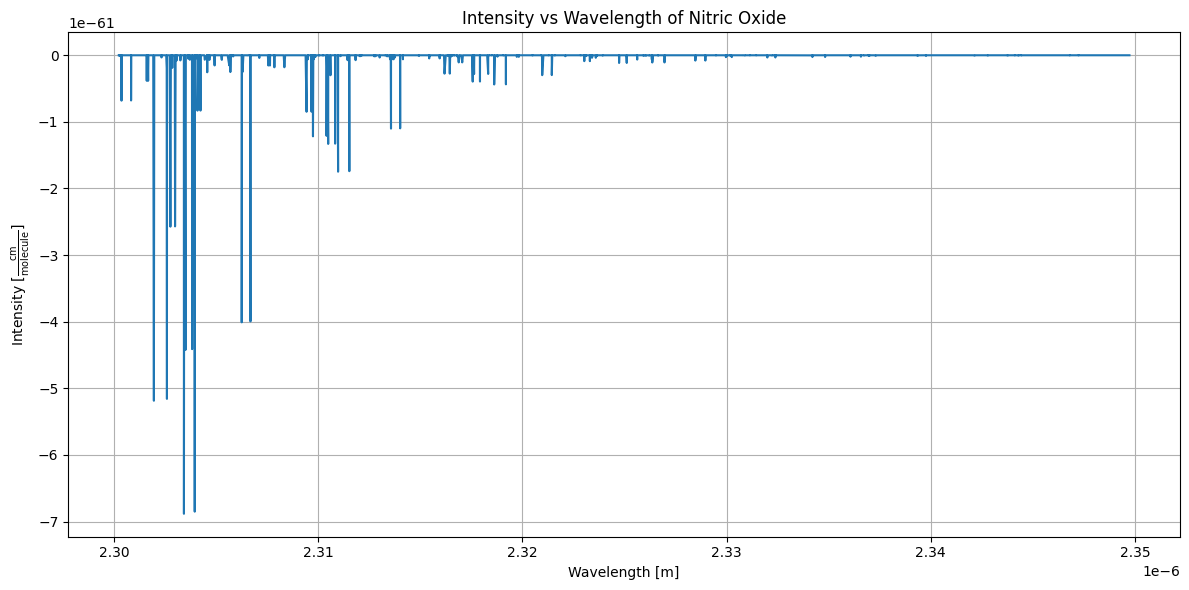

In [17]:
# file path to NO data
file_path_NO = '08_HITEMP2019.par'

# define fixed-width column specs and names
colspecs = [
    (0, 2),    # molecule number
    (2, 3),    # isotope number
    (3, 15),   # wavenumber [cm^-1]
    (15, 25),  # intensity [cm/molecule]
    (25, 30),  # air-broadened half-width
    (30, 35),  # self-broadened half-width
    (35, 45),  # lower state energy
]
names = ['molecule_number', 'isotope_number', 'wavenumber', 'intensity', 'air_half_width', 'self_half_width', 'lower_state_energy']

# read the data
df_NO = pd.read_fwf(file_path_NO, colspecs = colspecs, names = names)

# convert wavenumber to wavelength in meters
df_NO['wavelength_m'] = 1 / (100 * df_NO['wavenumber'])  # m

# sort for proper plotting
df_NO_sorted = df_NO.sort_values('wavelength_m')

# set wavelength range of interest (in meters)
wl_min = np.min(wavelength_121)
wl_max = np.max(wavelength_121)
df_NO_sorted = df_NO_sorted[(df_NO_sorted['wavelength_m'] >= wl_min) & (df_NO_sorted['wavelength_m'] <= wl_max)]

# visualize HITEMP emission spectrum
df_NO_sorted['intensity'] = -df_NO_sorted['intensity']
plt.figure(figsize = (12, 6))
plt.plot(df_NO_sorted['wavelength_m'], df_NO_sorted['intensity'])
plt.xlabel('Wavelength [m]')
plt.ylabel('Intensity [$\\frac{\\text{cm}}{\\text{molecule}}$]')
plt.title('Intensity vs Wavelength of Nitric Oxide')
plt.grid(True)
plt.tight_layout()
plt.show()

# save processed NO spectrum in the same format as the function above
filename_NO = "NO_spectrum.txt"
df_NO_save = df_NO_sorted[['wavelength_m', 'intensity']].copy()
df_NO_save.columns = ['wavelength', 'intensity']

# save to tab-separated file, without headers and keeping formatting
df_NO_save.to_csv(filename_NO, sep = '\t', index = False, header = False)

This repository also includes `NO_spectrum.txt` in case you're unable to download the data. Now we cross-correlate NO against the observed spectrum:

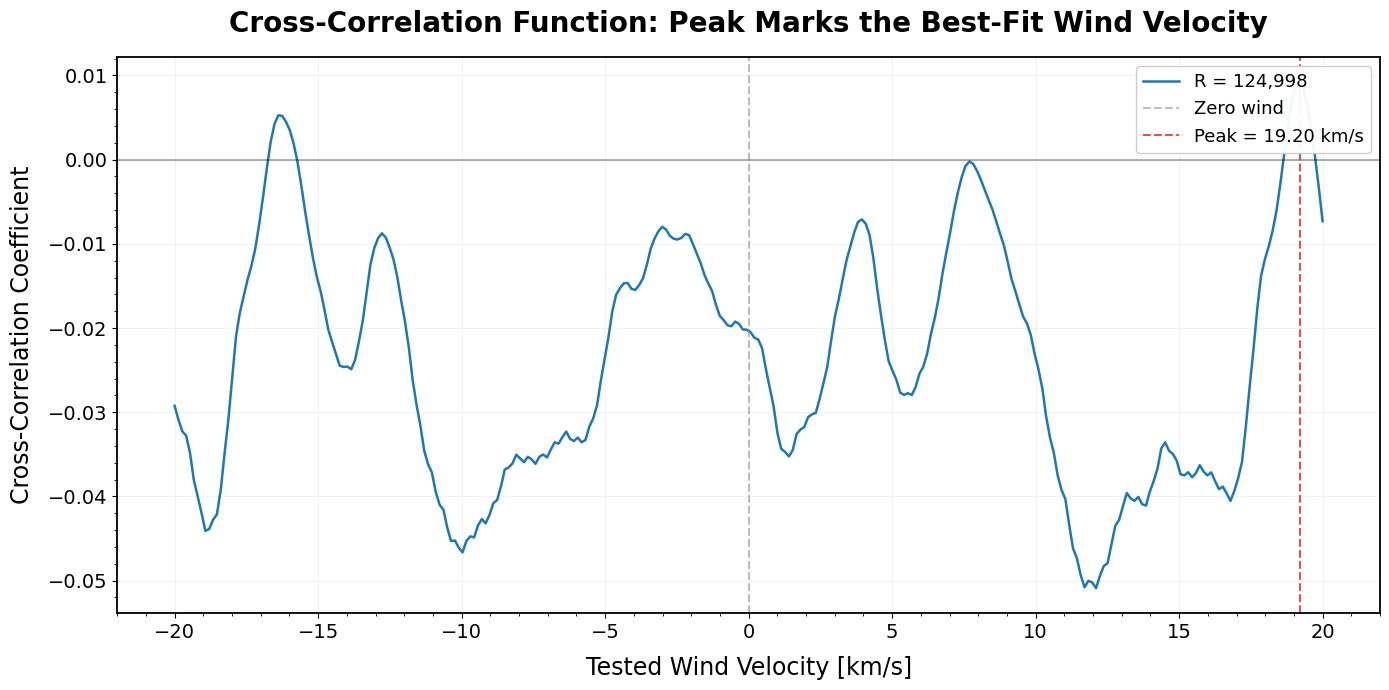

Velocity peak = 19.20 km/s
CCF peak strength = 0.0092


In [18]:
# load the NO template
filename_NO = 'NO_spectrum.txt'
df_NO_template = pd.read_csv(filename_NO, sep = '\t', header = None, names = ['wavelength', 'flux'])
wavelength_NO = df_NO_template['wavelength'].values
flux_NO = df_NO_template['flux'].values

# cross-correlate the NO template against the WASP-121b spectrum
vel_lags, ccf_vals, ccf_norm, v_peak = cross_correlation_velocity_shift(
    wavelength_off = wavelength_NO,
    flux_off       = flux_NO,
    wavelength_on  = wavelength_121,
    flux_on        = flux_121,
    R_target       = calculate_original_resolution(wavelength_121),
    velocity_range = 20,
    plot           = True
)

print(f'Velocity peak = {v_peak:.2f} km/s')
print(f'CCF peak strength = {np.max(ccf_vals):.4f}')

The cross-correlation for NO tells a very different story. The peak lands at 19.20 km/s, far from zero, and its correlation strength is only about 0.01, compared to CO's 0.25. This is the real signature of a non-detection: not just a peak in the wrong place, but a peak with essentially no correlation strength behind it.

This is the key comparison: a genuine detection shows both a clear peak near zero and meaningful correlation strength, while a non-detection shows neither. Together, these two results confirm that WASP-121b's spectrum contains CO, not NO.

With this, we've seen how cross-correlation works on simulated planetary spectra. Next, we'll extend the method to study atmospheric dynamics: measuring wind speed directly.

## Wind Speed Measurement

Cross-correlation isn't only useful for detecting composition, it can also reveal atmospheric dynamics, like wind speed. In this section, we use the custom cross-correlation function to estimate the wind speed on WASP-121b. This requires two spectra: one with no wind (Doppler off) and one with horizontal winds present (Doppler on). Cross-correlating the two and finding the peak velocity shift gives us the wind speed.

### Plotting Doppler-Off vs. Doppler-On Spectra

We load the Doppler-off (no wind) and Doppler-on (wind present) spectra of WASP-121b (Beltz & Rauscher, 2024), also available in this repository.

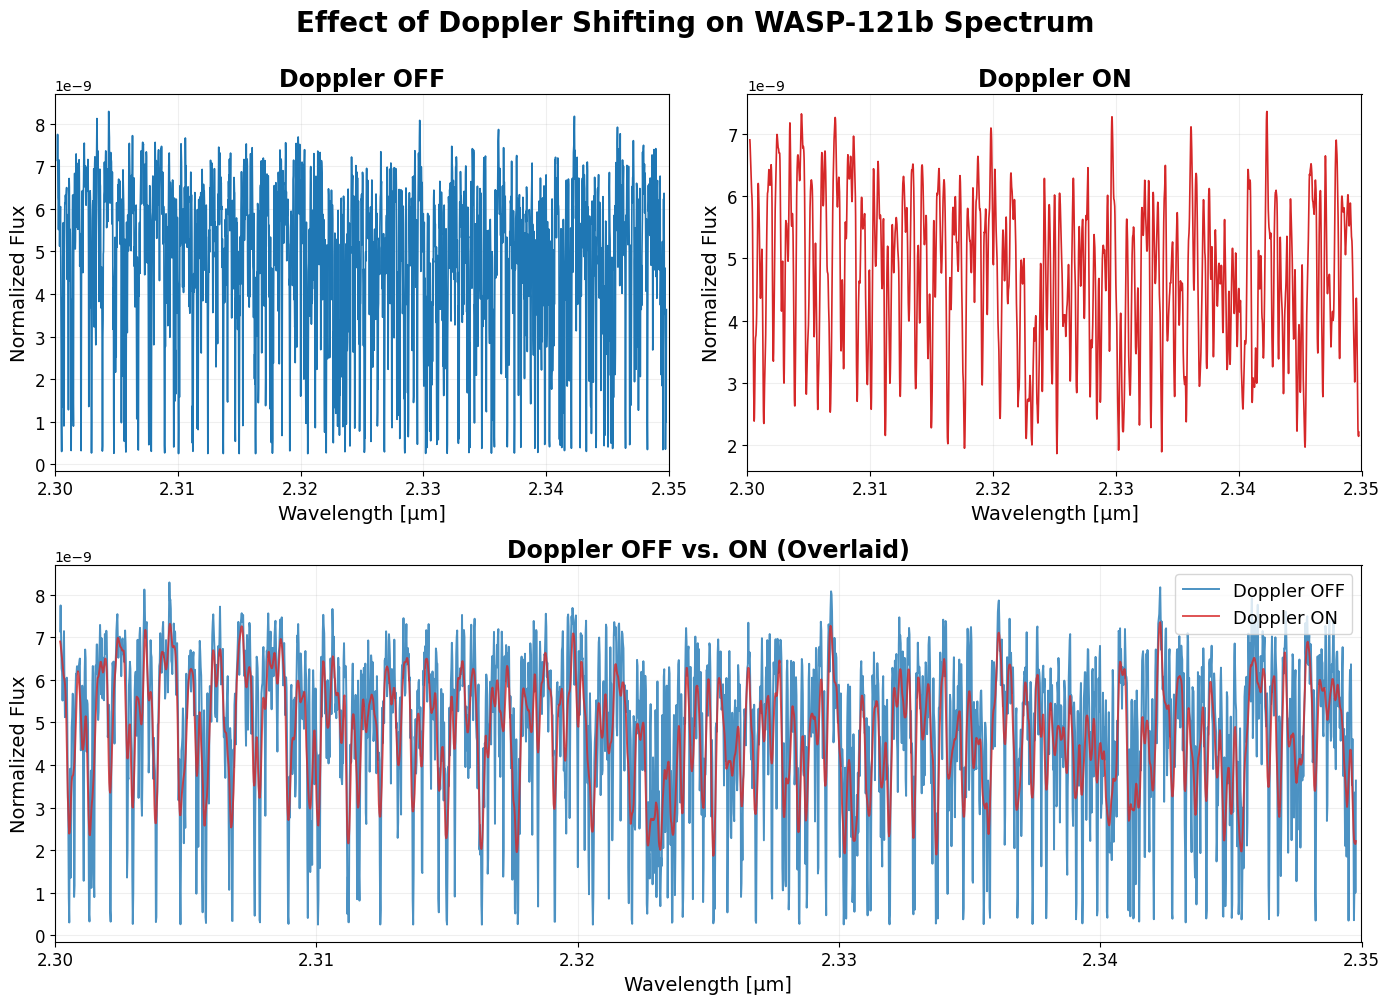

In [19]:
# read the doppler off and on spectra
filename_off = 'Ideal Data/WASP-121b/W121b_emission/W121b_0G/Dop_OFF/IR/Spec_0_asp-121b-0G_IR_phase_0.0_inc_00.00.0000.00.dat'
filename_on = 'Ideal Data/WASP-121b/W121b_emission/W121b_0G/Dop_ON/IR/Spec_1_asp-121b-0G_IR_phase_0.0_inc_00.00.0000.00.dat'

df_off = pd.read_csv(filename_off, sep = '\t', header = None, names = ['wavelength', 'flux']).iloc[10:-10]
df_on = pd.read_csv(filename_on, sep = '\t', header = None, names = ['wavelength', 'flux']).iloc[10:-10]

wavelength_off_um = df_off['wavelength'].values * 1e6
flux_off = df_off['flux'].values

wavelength_on_um = df_on['wavelength'].values * 1e6
flux_on = df_on['flux'].values

# zoom window where individual lines are visible
x_min, x_max = 2.30, 2.35

# 3-panel layout: doppler off, doppler on, and both overlaid
fig = plt.figure(figsize = (14, 10))
fig.patch.set_facecolor('white')

ax1 = plt.subplot2grid((2, 2), (0, 0))
ax2 = plt.subplot2grid((2, 2), (0, 1))
ax3 = plt.subplot2grid((2, 2), (1, 0), colspan = 2)

# top-left: doppler off
ax1.plot(wavelength_off_um, flux_off, linewidth = 1.2, color = '#1f77b4')
ax1.set_xlim(x_min, x_max)
ax1.set_title('Doppler OFF', fontsize = 17, weight = 'bold')
ax1.set_xlabel('Wavelength [μm]', fontsize = 14)
ax1.set_ylabel('Normalized Flux', fontsize = 14)
ax1.grid(True, alpha = 0.2)
ax1.tick_params(labelsize = 12)

# top-right: doppler on
ax2.plot(wavelength_on_um, flux_on, linewidth = 1.2, color = '#d62728')
ax2.set_xlim(x_min, x_max)
ax2.set_title('Doppler ON', fontsize = 17, weight = 'bold')
ax2.set_xlabel('Wavelength [μm]', fontsize = 14)
ax2.set_ylabel('Normalized Flux', fontsize = 14)
ax2.grid(True, alpha = 0.2)
ax2.tick_params(labelsize = 12)

# bottom: both overlaid
ax3.plot(wavelength_off_um, flux_off, linewidth = 1.4, color = '#1f77b4', label = 'Doppler OFF', alpha = 0.8)
ax3.plot(wavelength_on_um, flux_on, linewidth = 1.4, color = '#d62728', label = 'Doppler ON', alpha = 0.8)
ax3.set_xlim(x_min, x_max)
ax3.set_title('Doppler OFF vs. ON (Overlaid)', fontsize = 17, weight = 'bold')
ax3.set_xlabel('Wavelength [μm]', fontsize = 14)
ax3.set_ylabel('Normalized Flux', fontsize = 14)
ax3.legend(fontsize = 13, loc = 'upper right')
ax3.grid(True, alpha = 0.2)
ax3.tick_params(labelsize = 12)

fig.suptitle('Effect of Doppler Shifting on WASP-121b Spectrum', fontsize = 20, weight = 'bold', y = 1.00)

plt.tight_layout()
plt.show()

The wind-broadened lines in the Doppler ON panel are visibly shifted and slightly broadened relative to the Doppler OFF case, this is the signature cross-correlation will pick up.

### Estimating Wind Speed at Full Resolution

We cross-correlate the Doppler-on and Doppler-off spectra to find the wind speed at the planet's intrinsic resolution. The static plot below shows the final result; the video after it shows the template sliding across the real spectrum as the correlation builds up.

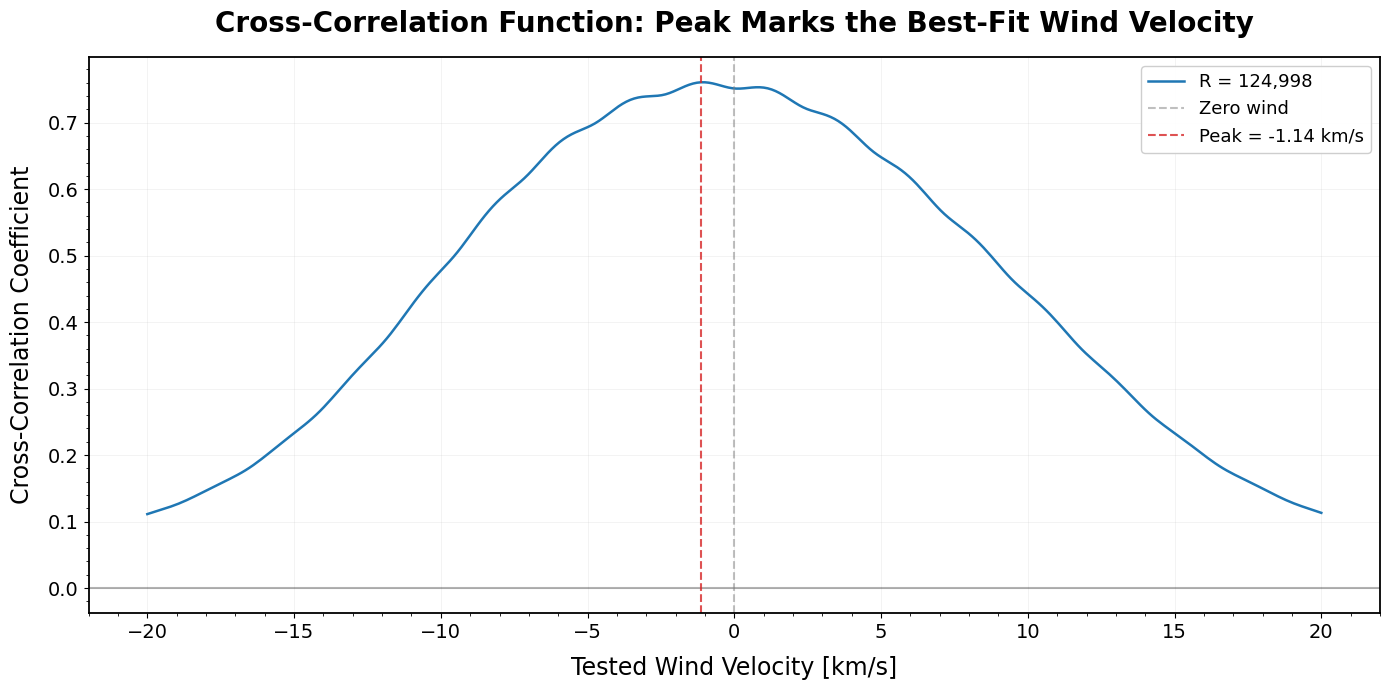

Velocity peak = -1.14 km/s
CCF peak strength = 0.7606


In [20]:
# calculate original resolving power from the doppler-off spectrum
wavelength_off = df_off['wavelength'].values
wavelength_on = df_on['wavelength'].values
flux_off_raw = flux_off
flux_on_raw = flux_on

N = len(wavelength_off)
delta_lambda_orig = (wavelength_off[-1] - wavelength_off[0]) / (N - 1)
lambda_mid_full = np.median(wavelength_off)
R_orig = lambda_mid_full / delta_lambda_orig

# cross-correlate at full (intrinsic) resolution
vel_lags, ccf_vals, ccf_norm, v_peak = cross_correlation_velocity_shift(
    wavelength_off = wavelength_off,
    flux_off       = flux_off_raw,
    wavelength_on  = wavelength_on,
    flux_on        = flux_on_raw,
    R_target       = R_orig,
    velocity_range = 20,
    plot           = True
)

print(f'Velocity peak = {v_peak:.2f} km/s')
print(f'CCF peak strength = {np.max(ccf_vals):.4f}')

The peak marks the planet's horizontal wind speed at full resolution. Keep in mind: measurements taken at different orbital phases can show different wind speeds, since atmospheric dynamics change across the planet's orbit, and this value reflects the intrinsic, high-resolution signal, an instrument with lower resolution may not recover it exactly.

The video below shows the same cross-correlation as an animated sweep across the real WASP-121b spectrum, so you can watch the template align and the CCF build toward its peak.

In [21]:
# define speed of light
c_kms = 299792.458

# shared wavelength region between the two spectra
min_wl_shared = max(np.min(wavelength_off), np.min(wavelength_on))
max_wl_shared = min(np.max(wavelength_off), np.max(wavelength_on))
mask_off = (wavelength_off >= min_wl_shared) & (wavelength_off <= max_wl_shared)
mask_on = (wavelength_on >= min_wl_shared) & (wavelength_on <= max_wl_shared)

wavelength_off_shared = wavelength_off[mask_off]
flux_off_shared = flux_off_raw[mask_off]
wavelength_on_shared = wavelength_on[mask_on]
flux_on_shared = flux_on_raw[mask_on]

sort_idx_off = np.argsort(wavelength_off_shared)
sort_idx_on = np.argsort(wavelength_on_shared)
wavelength_off_sorted = wavelength_off_shared[sort_idx_off]
flux_off_sorted = flux_off_shared[sort_idx_off]
wavelength_on_sorted = wavelength_on_shared[sort_idx_on]
flux_on_sorted = flux_on_shared[sort_idx_on]

valid_off = np.isfinite(flux_off_sorted) & np.isfinite(wavelength_off_sorted)
valid_on = np.isfinite(flux_on_sorted) & np.isfinite(wavelength_on_sorted)
wavelength_off_clean = wavelength_off_sorted[valid_off]
flux_off_clean = flux_off_sorted[valid_off]
wavelength_on_clean = wavelength_on_sorted[valid_on]
flux_on_clean = flux_on_sorted[valid_on]

# interpolate the doppler-on flux onto the doppler-off wavelength grid
flux_on_interp = np.interp(wavelength_off_clean, wavelength_on_clean, flux_on_clean)

# mean-subtract for the ccf math
template = flux_off_clean - np.mean(flux_off_clean)
observed = flux_on_interp - np.mean(flux_on_interp)

# velocity grid
velocity_range = 20
nc = 300
velocity_lags = np.linspace(-velocity_range, velocity_range, nc)
ccf = np.zeros_like(velocity_lags)

delta_lambda = wavelength_off_clean[1] - wavelength_off_clean[0]
lambda_mid = np.median(wavelength_off_clean)
N_full = len(template)
indices = np.arange(N_full)

# spline for the ccf math (mean-subtracted)
template_spline = splrep(indices, template, s = 0)

# spline for display (the real, normalized flux values)
template_display_spline = splrep(indices, flux_off_clean, s = 0)

weight = np.ones(N_full)
edge_width = int(N_full * 0.1)
for j in range(edge_width):
    weight[j] = (j / edge_width)
    weight[-(j + 1)] = (j / edge_width)

shifted_templates_display = np.zeros((nc, N_full))

for i, v in enumerate(velocity_lags):
    shift_pixels = -(lambda_mid * (v / c_kms)) / delta_lambda
    shifted_indices = indices + shift_pixels

    template_shifted = splev(shifted_indices, template_spline)
    shifted_templates_display[i] = splev(shifted_indices, template_display_spline)

    template_weighted = template_shifted * weight
    observed_weighted = observed * weight
    sum_weights = np.sum(weight)
    R_x = np.sum(template_weighted * observed_weighted) / sum_weights
    var_t = np.sum(weight * (template_weighted - np.average(template_weighted, weights = weight)) ** 2) / sum_weights
    var_o = np.sum(weight * (observed_weighted - np.average(observed_weighted, weights = weight)) ** 2) / sum_weights
    ccf[i] = R_x / np.sqrt(var_t * var_o)

v_peak_anim = velocity_lags[np.argmax(ccf)]
wavelength_um = wavelength_off_clean * 1e6

# two-panel figure: spectrum on the left, ccf building up on the right
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (14, 7))
fig.patch.set_facecolor('white')

ax1.plot(wavelength_um, flux_on_interp, color = '#d62728', linewidth = 1.5, alpha = 0.8, label = 'Observed (Doppler ON)')
template_line, = ax1.plot([], [], color = '#1f77b4', linewidth = 2, alpha = 0.5, label = 'Template (sliding)')
ax1.set_xlim(x_min, x_max)
ax1.set_ylim(np.min(flux_on_interp), np.max(flux_on_interp))
ax1.set_xlabel('Wavelength [μm]', fontsize = 15)
ax1.set_ylabel('Normalized Flux', fontsize = 15)
ax1.set_title('Sliding the Template', fontsize = 17, weight = 'bold')
ax1.legend(fontsize = 11, loc = 'lower right')
ax1.grid(True, alpha = 0.2)
ax1.tick_params(labelsize = 12)

ccf_line, = ax2.plot([], [], linewidth = 2.5, color = '#2ca02c')
point, = ax2.plot([], [], 'o', color = 'black', markersize = 8)

peak_vline = ax2.axvline(v_peak_anim, color = 'black', linestyle = '--', linewidth = 1.5, alpha = 0)
peak_text = ax2.text(v_peak_anim, max(ccf) * 1.02, '', fontsize = 13, weight = 'bold', color = 'black', ha = 'center', va = 'bottom')

ax2.set_xlim(velocity_lags.min(), velocity_lags.max())
ax2.set_ylim(min(ccf) - 0.05 * abs(min(ccf)), max(ccf) * 1.15)
ax2.set_xlabel('Trial Velocity [km/s]', fontsize = 15)
ax2.set_ylabel('Normalized CCF', fontsize = 15)
ax2.set_title('Cross-Correlation Function', fontsize = 17, weight = 'bold')
ax2.grid(True, alpha = 0.2)
ax2.tick_params(labelsize = 12)

fig.subplots_adjust(top = 0.88, bottom = 0.13, left = 0.06, right = 0.98, wspace = 0.22)

# hold on the final frame so the peak is easy to read
hold_frames = 30
frame_indices = list(range(len(velocity_lags))) + [len(velocity_lags) - 1] * hold_frames

def update(frame_idx):
    idx = frame_indices[frame_idx]
    template_line.set_data(wavelength_um, shifted_templates_display[idx])
    ccf_line.set_data(velocity_lags[:idx + 1], ccf[:idx + 1])
    point.set_data([velocity_lags[idx]], [ccf[idx]])

    if velocity_lags[idx] >= v_peak_anim:
        peak_vline.set_alpha(0.8)
        peak_text.set_text(f'Peak = {v_peak_anim:.2f} km/s')

    return template_line, ccf_line, point, peak_vline, peak_text

ani = animation.FuncAnimation(fig, update, frames = len(frame_indices), interval = 50, blit = False)
ani.save('cross_correlation_real_data.mp4', writer = 'ffmpeg', fps = 20, dpi = 150)
plt.close(fig)

<video controls width="100%">
  <source src="cross_correlation_real_data.mp4" type="video/mp4">
  Your browser does not support the video tag.
</video>

### Effects of Instrument Resolution on Wind Speed Measurement

Now let's see what happens to the wind speed measurement as spectral resolution drops. We repeat the same cross-correlation across a range of resolutions, from the original down to a much coarser value, and compare the resulting CCFs directly.

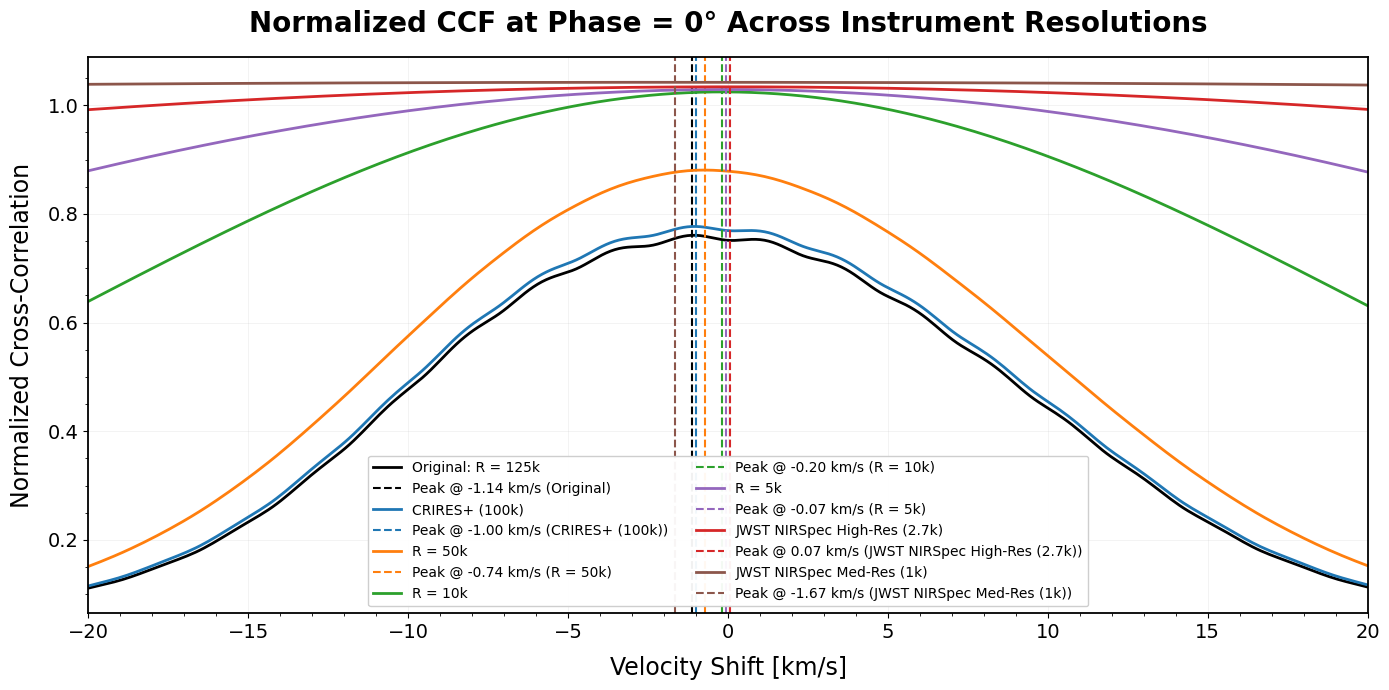

In [22]:
# read the doppler off and on spectra (phase 0)
filename_off = 'Ideal Data/WASP-121b/W121b_emission/W121b_0G/Dop_OFF/IR/Spec_0_asp-121b-0G_IR_phase_0.0_inc_00.00.0000.00.dat'
filename_on = 'Ideal Data/WASP-121b/W121b_emission/W121b_0G/Dop_ON/IR/Spec_1_asp-121b-0G_IR_phase_0.0_inc_00.00.0000.00.dat'

df_off = pd.read_csv(filename_off, sep = '\t', header = None, names = ['wavelength', 'flux']).iloc[10:-10]
df_on = pd.read_csv(filename_on, sep = '\t', header = None, names = ['wavelength', 'flux']).iloc[10:-10]

wl_off = df_off['wavelength'].values
fl_off = df_off['flux'].values
wl_on = df_on['wavelength'].values
fl_on = df_on['flux'].values

# cross-correlation at the original resolution
vel_lags_orig, ccf_orig, ccf_norm_orig, v_peak_orig = cross_correlation_velocity_shift(
    wavelength_off = wl_off,
    flux_off       = fl_off,
    wavelength_on  = wl_on,
    flux_on        = fl_on,
    R_target       = R_orig,
    velocity_range = 20,
    plot           = False
)

# resolutions to compare directly
resolutions = [100000, 50000, 10000, 5000, 2700, 1000]
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:purple', 'tab:red', 'tab:brown']
labels = ['CRIRES+ (100k)', 'R = 50k', 'R = 10k', 'R = 5k', 'JWST NIRSpec High-Res (2.7k)', 'JWST NIRSpec Med-Res (1k)']
ccf_data = []

for R, color, label in zip(resolutions, colors, labels):
    vel_lags, ccf, ccf_norm, v_peak = cross_correlation_velocity_shift(
        wavelength_off = wl_off,
        flux_off       = fl_off,
        wavelength_on  = wl_on,
        flux_on        = fl_on,
        R_target       = R,
        velocity_range = 20,
        plot           = False
    )
    ccf_data.append((vel_lags, ccf, v_peak, color, label))

rounded_R_orig_label = f'{round(R_orig / 1000):.0f}k'

# set up the plot
fig, ax = plt.subplots(figsize = (14, 7))
fig.patch.set_facecolor('white')

ax.plot(vel_lags_orig, ccf_orig, label = f'Original: R = {rounded_R_orig_label}', color = 'black', linewidth = 2)
ax.axvline(v_peak_orig, color = 'black', linestyle = '--', label = f'Peak @ {v_peak_orig:.2f} km/s (Original)')

for vel_lags, ccf, v_peak, color, label in ccf_data:
    ax.plot(vel_lags, ccf, label = label, color = color, linewidth = 2)
    ax.axvline(v_peak, color = color, linestyle = '--', label = f'Peak @ {v_peak:.2f} km/s ({label})')

ax.set_title('Normalized CCF at Phase = 0° Across Instrument Resolutions', fontsize = 20, weight = 'bold', pad = 18)
ax.set_xlabel('Velocity Shift [km/s]', fontsize = 17, labelpad = 10)
ax.set_ylabel('Normalized Cross-Correlation', fontsize = 17, labelpad = 10)
ax.set_xlim(-20, 20)

ax.legend(fontsize = 10, loc = 'best', ncol = 2, framealpha = 0.95)
ax.grid(True, alpha = 0.2, linestyle = '-', linewidth = 0.5)
ax.set_facecolor('white')

for spine in ax.spines.values():
    spine.set_linewidth(1.3)

ax.minorticks_on()
ax.tick_params(axis = 'both', which = 'major', labelsize = 14)
ax.tick_params(axis = 'both', which = 'minor', labelsize = 12)

plt.tight_layout()
plt.show()

Lower resolution flattens and shifts the CCF peak, exactly the effect we saw earlier with the spectrum itself: less resolved detail means a less precise velocity measurement. The video below shows this as a continuous sweep, watch how the CCF broadens and its peak drifts as resolution decreases.

In [23]:
# continuous sweep in log space from the original resolution down to a low value
n_frames = 60
R_sequence_wind = np.logspace(np.log10(R_orig), np.log10(1000), n_frames)

# precompute the ccf at each resolution in the sweep
ccf_sequence = []
peak_sequence = []
vel_lags_ref = None
for R in R_sequence_wind:
    vel_lags_r, ccf_r, ccf_norm_r, v_peak_r = cross_correlation_velocity_shift(
        wavelength_off = wl_off,
        flux_off       = fl_off,
        wavelength_on  = wl_on,
        flux_on        = fl_on,
        R_target       = R,
        velocity_range = 20,
        plot           = False
    )
    ccf_sequence.append(ccf_r)
    peak_sequence.append(v_peak_r)
    if vel_lags_ref is None:
        vel_lags_ref = vel_lags_r

fig, ax = plt.subplots(figsize = (14, 7))
fig.patch.set_facecolor('white')

ccf_line, = ax.plot([], [], color = '#1f77b4', linewidth = 2)
point, = ax.plot([], [], 'o', color = '#d62728', markersize = 8)

ax.set_xlim(vel_lags_ref.min(), vel_lags_ref.max())
ax.set_ylim(min(min(c) for c in ccf_sequence) - 0.05, 1.15)
ax.set_xlabel('Velocity Shift [km/s]', fontsize = 15)
ax.set_ylabel('Normalized Cross-Correlation', fontsize = 15)
ax.grid(True, alpha = 0.2)
ax.tick_params(labelsize = 12)

title = ax.set_title('', fontsize = 17, weight = 'bold')
peak_text = ax.text(0.02, 0.95, '', transform = ax.transAxes, fontsize = 13, weight = 'bold', color = '#d62728', va = 'top')

def update(frame):
    ccf_frame = ccf_sequence[frame]
    peak_idx = np.argmax(ccf_frame)
    peak_vel = vel_lags_ref[peak_idx]

    ccf_line.set_data(vel_lags_ref, ccf_frame)
    point.set_data([peak_vel], [ccf_frame[peak_idx]])

    title.set_text(f'CCF at R = {R_sequence_wind[frame]:,.0f}')
    peak_text.set_text(f'Peak velocity: {peak_sequence[frame]:.2f} km/s')

    return ccf_line, point, title, peak_text

ani = animation.FuncAnimation(fig, update, frames = n_frames, interval = 50, blit = False)

# requires ffmpeg to be installed on your system (or pip install imageio-ffmpeg)
ani.save('ccf_resolution_sweep.mp4', writer = 'ffmpeg', dpi = 120)
plt.close(fig)

<video controls width="100%">
  <source src="ccf_resolution_sweep.mp4" type="video/mp4">
  Your browser does not support the video tag.
</video>

To see this more clearly as a number rather than a shape, it helps to look at the *difference* between each resolution's measured velocity and the true, full-resolution value.

### Resolution vs. Wind Speed Measurement Accuracy

The plot below shows exactly that: how far the measured velocity strays from the true value as resolution decreases.

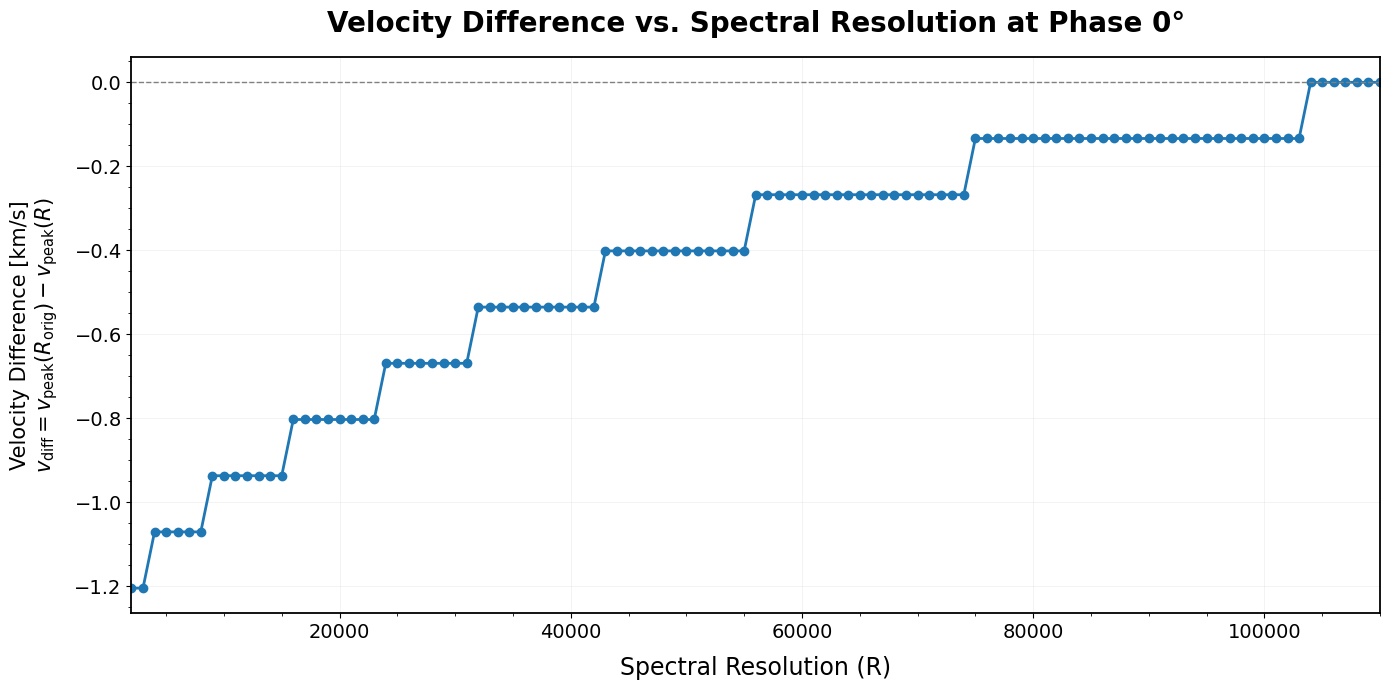

In [24]:
# resolutions to test, from the original down to a lower bound
R_values = sorted(set(np.arange(2000, int(R_orig) + 1, 1000).tolist() + [int(R_orig)]))

# cross-correlate at each resolution
results = []
for R in R_values:
    try:
        vel_lags, ccf, ccf_norm, v_peak = cross_correlation_velocity_shift(
            wavelength_off = wl_off,
            flux_off       = fl_off,
            wavelength_on  = wl_on,
            flux_on        = fl_on,
            R_target       = R,
            velocity_range = 20,
            plot           = False
        )
        results.append({'resolution': R, 'v_peak': v_peak})
    except Exception as e:
        print(f'Error at R {R}: {e}')

df_resolution_sweep = pd.DataFrame(results)

fig, ax = plt.subplots(figsize = (14, 7))
fig.patch.set_facecolor('white')

v_ref = df_resolution_sweep[df_resolution_sweep['resolution'] == int(R_orig)]['v_peak'].values[0]
df_resolution_sweep['v_diff'] = v_ref - df_resolution_sweep['v_peak']

ax.plot(df_resolution_sweep['resolution'], df_resolution_sweep['v_diff'], marker = 'o', markersize = 6, linestyle = '-', linewidth = 2, color = '#1f77b4')

ax.set_title('Velocity Difference vs. Spectral Resolution at Phase 0°', fontsize = 20, weight = 'bold', pad = 18)
ax.set_xlabel('Spectral Resolution (R)', fontsize = 17, labelpad = 10)
ax.set_ylabel('Velocity Difference [km/s]\n' + r'$v_\mathrm{diff} = v_\mathrm{peak}(R_\mathrm{orig}) - v_\mathrm{peak}(R)$', fontsize = 15, labelpad = 10)

ax.axhline(y = 0, color = 'grey', linestyle = '--', linewidth = 1)
ax.set_xlim(left = min(R_values), right = 110000)

ax.grid(True, alpha = 0.2, linestyle = '-', linewidth = 0.5)
ax.set_facecolor('white')

for spine in ax.spines.values():
    spine.set_linewidth(1.3)

ax.minorticks_on()
ax.tick_params(axis = 'both', which = 'major', labelsize = 14)
ax.tick_params(axis = 'both', which = 'minor', labelsize = 12)

plt.tight_layout()
plt.show()

Once resolution climbs high enough, the velocity difference converges to zero, meaning the measured wind speed matches the true value, even though the number of resolved data points is still reduced along the way. Ground-based high-resolution instruments can measure wind speeds accurately, though telluric absorption adds its own uncertainty. Space-based instruments avoid that atmospheric contamination but generally run at lower resolution, trading precision for a cleaner signal. Choosing the right instrument means balancing resolution, observing environment, and noise, exactly the tradeoff this whole tutorial has been building toward.

## End of Tutorial

Congratulations, you've reached the end of this tutorial. Along the way, you've learned how to perform cross-correlation on exoplanet spectra, both to detect molecular composition and to measure wind speed in an exoplanet's atmosphere.

We prepared observational and molecular template datasets, converted absorption spectra to emission where needed, and built a custom cross-correlation function from scratch. Using 3D model data for WASP-121b, we confirmed the presence of carbon monoxide, a clear peak near 0 km/s with meaningful correlation strength, while nitric oxide showed no real correlation at all, confirming it isn't present in the atmosphere.

We then extended the method to atmospheric dynamics. By comparing Doppler-off (no wind) and Doppler-on (wind present) spectra, we measured wind speed and watched how instrument resolution affects that measurement's accuracy. High-resolution instruments like CRIRES+ recover the true wind speed reliably, while lower-resolution instruments like JWST NIRSpec can underestimate it, since coarser resolution smooths away the fine spectral detail the measurement depends on.

This tutorial is meant to be a starting point, not an endpoint. The same methods extend naturally to other targets, other molecular species, and other instruments, adapt them to whatever dataset or question you're working on next.

Thanks for following along. You now have a working foundation in cross-correlation techniques for exoplanet spectroscopy, and a base to build on for your own research into exoplanet composition and atmospheric dynamics.

## References

Beltz, H., & Rauscher, E. (2024). Comparative Planetology of Magnetic Effects in Ultrahot Jupiters: Trends in High-resolution Spectroscopy. The Astrophysical Journal, 962(1), 24. [https://ui.adsabs.harvard.edu/abs/2024ApJ…976…32B/abstract](https://ui.adsabs.harvard.edu/abs/2024ApJ…976…32B/abstract)

Birkby, J. L. (2018). Exoplanet atmospheres at high spectral resolution. arXiv. [https://doi.org/10.48550/arXiv.1806.04617](https://doi.org/10.48550/arXiv.1806.04617)

Bourrier, V., Ehrenreich, D., Lendl, M., Cretignier, M., Allart, R., Dumusque, X., Cegla, H. M., Suárez-Mascareño, A., Wyttenbach, A., Hoeijmakers, H. J., Melo, C., Kuntzer, T., Astudillo-Defru, N., Giles, H., Heng, K., Kitzmann, D., Lavie, B., Lovis, C., Murgas, F., & Nascimbeni, V. (2020). Hot Exoplanet Atmospheres Resolved with Transit Spectroscopy (HEARTS). III. Atmospheric structure of the misaligned ultra-hot Jupiter WASP-121b. Astronomy & Astrophysics, 635, A205. [https://ui.adsabs.harvard.edu/abs/2020A%26A…635A.205B/abstract](https://ui.adsabs.harvard.edu/abs/2020A%26A…635A.205B/abstract)

Follert, R., Dorn, R. J., Oliva, E., Lizon, J. L., Hatzes, A., Piskunov, N., Reiners, A., Seemann, U., Stempels, E., Heiter, U., Marquart, T., Lockhart, M., Anglada-Escudé, G., Löwinger, T., Baade, D., Grunhut, J., Bristow, P., Klein, B., Jung, Y., Ives, D. J., Kerber, F., Pozna, E., Paufique, J., Kaeufl, H. U., Origlia, L., Valenti, E., Gojak, D., Hilker, M., Pasquini, L., Smette, A., & Smoker, J. (n.d.). CRIRES+: A cross-dispersed high-resolution infrared spectrograph for the ESO VLT. European Southern Observatory. [https://www.eso.org/sci/facilities/develop/instruments/CRIRES_up/CRIRES_up_Overview.pdf](https://www.eso.org/sci/facilities/develop/instruments/CRIRES_up/CRIRES_up_Overview.pdf)

Harris, C. R., Millman, K. J., van der Walt, S. J., et al. (2020). Array programming with NumPy. Nature, 585, 357–362. [https://arxiv.org/pdf/2006.10256](https://arxiv.org/pdf/2006.10256)

Labiano, A., Argyriou, I., Álvarez-Márquez, J., Glasse, A., Glauser, A., Patapis, P., Law, D., Brandl, B. R., Justtanont, K., Lahuis, F., Martínez-Galarza, J. R., Mueller, M., Noriega-Crespo, A., Royer, P., Shaughnessy, B., & Vandenbussche, B. (2021). Wavelength calibration and resolving power of the JWST MIRI Medium Resolution Spectrometer. Astronomy & Astrophysics, 656, A135. [https://doi.org/10.1051/0004-6361/202140614](https://doi.org/10.1051/0004-6361/202140614)

Linsky, J. L., Tripp, T. M., Redfield, S., & France, K. (2025). The case for high resolution spectroscopy in the ultraviolet. arXiv. [https://arxiv.org/abs/2504.00231](https://arxiv.org/abs/2504.00231)

Snellen, I. A. G., de Kok, R. J., de Mooij, E. J. W., & Albrecht, S. (2010). The orbital motion, absolute mass and high-altitude winds of exoplanet HD 209458b. Nature, 465(7301), 1049–1051. [https://ui.adsabs.harvard.edu/abs/2010Natur.465.1049S/abstract](https://ui.adsabs.harvard.edu/abs/2010Natur.465.1049S/abstract)

Virtanen, P., Gommers, R., Oliphant, T. E., Haberland, M., Reddy, T., Cournapeau, D., Burovski, E., Peterson, P., Weckesser, W., Bright, J., van der Walt, S. J., Brett, M., Wilson, J., Millman, K. J., Mayorov, N., Nelson, A. R. J., Jones, E., Kern, R., Larson, E., Carey, C. J., Polat, İ., Feng, Y., Moore, E. W., VanderPlas, J., Laxalde, D., Perktold, J., Cimrman, R., Henriksen, I., Quintero, E. A., Harris, C. R., Archibald, A. M., Ribeiro, A. H., Pedregosa, F., van Mulbregt, P., & SciPy 1.0 Contributors. (2020). SciPy 1.0: Fundamental algorithms for scientific computing in Python. Nature Methods, 17, 261–272. [https://arxiv.org/pdf/1907.10121](https://arxiv.org/pdf/1907.10121)

## About This Notebook

**Author:** Sarunyapat (Pat) Phoompuang, Imperial College London ([sphoom22@terpmail.umd.edu](mailto:sphoom22@terpmail.umd.edu))
**Research Advisor:** Dr. Hayley Beltz, University of Kansas ([hbeltz@ku.edu](mailto:hbeltz@ku.edu))

Last updated: September, 2026.